# [Cell 00] Evaluasi CAG, RAG, dan Hybrid CAG-RAG — Wisata Danau Toba

Judul: *Analysis of Pure CAG, Pure RAG, and Hybrid CAG-RAG for Retrieval Latency and Answer Quality*

**Catatan sebelum evaluasi:** bersihkan KV-Cache dulu secara manual dari terminal supaya hasil tidak dipengaruhi cache sebelumnya.

### Dataset Evaluasi (200 query)
| Subset | Jumlah | Sumber |
|--------|--------|--------|
| FAQ (ground-truth) | 100 | `database/FAQ/dataset_faq.json` |
| Questioner (question-only) | 100 | `database/FAQ/dataset_questioner.json` |

### Inti Skenario
Notebook ini membandingkan 3 framework pada 200 query yang sama:

- **Pure CAG**: cache-based dengan dua layer (**FAQ similarity** lalu **KV-Cache**) tanpa RAG fallback. Implementasi evaluasi tidak mengambil jawaban langsung dari ground-truth (anti-cheating).
- **Pure RAG**: retrieval-only. Semua 200 query dijawab melalui retrieval dari PDF, lalu fallback ke internet bila jawaban belum ditemukan.
- **Hybrid CAG-RAG**: cache-first. Query dicoba via FAQ/KV-Cache terlebih dulu, lalu fallback ke RAG untuk retrieval dari PDF dan internet.

### Metrik Evaluasi

**1. Retrieval Latency Metrics**
- Response Time Avg
- Cache Hit Rate (CHR)
- Speedup Factor

**2. Retrieval Inaccuracy Metrics**
- Relevance Score
- Exact Match (EM)
- Effective Information Rate (EIR)
- RAG Recall
- BERTScore F1
- Completeness
- Hallucination Rate

### Ringkasan Peran Framework
| Framework | Peran Utama | Harapan Hasil |
|-----------|-------------|----------------|
| Pure CAG | FAQ similarity + KV-Cache (tanpa RAG fallback) | Cepat untuk cache hit, miss tetap miss, dan pengujian tetap fair | 
| Pure RAG | Retrieval penuh | Semua query bisa dijawab lewat retrieval PDF + internet fallback |
| Hybrid CAG-RAG | Cache-first + RAG fallback | Menggabungkan kecepatan cache dan cakupan retrieval |


## [Cell 01] 📝 Catatan Revisi Metodologi (v3 — SBERT Lokal)

**Status metrik per subset (lihat juga Cara 1 & 2 di awal notebook):**
- **FAQ (100 query, punya $K$/ground truth):** seluruh 10 metrik terisi penuh.
- **Questionnaire (100 query, tanpa $K$/ground truth):**
  - **Terisi** (reference-free, SBERT lokal): *Relevance Score*, *Hallucination
    Rate* (vs konteks retrieval), *EIR* (jika konteks tersedia), serta Latency &
    CHR.
  - **`NaN`** (wajib butuh ground truth/$K$): *Exact Match*, *BERTScore F1*,
    *Completeness*, *RAG Recall*. Saat agregasi, `np.nanmean()` mengabaikan
    `NaN` sehingga rata-rata akhir tetap dihitung dari 100 data FAQ yang
    memiliki nilai (lihat [Cell 44]).

**Catatan keterbatasan yang masih terbuka:**
- Penilaian *Completeness*/*RAG Recall* memakai threshold tunggal (0.70) dan
  *Hallucination* memakai threshold tunggal (0.40) untuk *cosine similarity*
  SBERT — nilai ini perlu disebutkan secara eksplisit sebagai parameter
  metodologi di Bab 3, dan idealnya divalidasi dengan beberapa sampel manual.
- Ekstraksi key points $K$ ([Cell 13]) masih memanggil LLM (Gemini) satu kali
  per item FAQ (hasilnya di-*cache* ke `key_points_cache.json` sehingga hanya
  berjalan sekali). Ini di luar scope revisi v3, karena revisi v3 hanya
  menyasar komponen *judging*, bukan ekstraksi $K$.


## [Cell 02] Setup Environment

In [1]:
# [Cell 03]
# Install Dependencies
# %pip install -q python-dotenv sentence-transformers langchain langchain-community langchain-huggingface faiss-cpu bert-score pandas matplotlib seaborn scipy nltk

In [2]:
# [Cell 04]
# Setup & Imports
import sys, os, json, time, warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from datetime import datetime
from scipy import stats
import scipy
import nltk
nltk.download('punkt_tab', quiet=True)
nltk.download('punkt', quiet=True)
from bert_score import score as bert_score_fn
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings
from dotenv import load_dotenv

# -- Path & env ------------------------------------------------------------
sys.path.append(os.path.abspath('../src'))
load_dotenv()

# -- Import evaluation classes dari evaluation.py -------------------------
from evaluation import QuantitativeMetrics, PerformanceEvaluator, QueryMetrics

# -- Plot style -----------------------------------------------------------
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

print("✅ Setup complete")
print(f"   scipy        : {scipy.__version__}")
print(f"   evaluation.py: QuantitativeMetrics, PerformanceEvaluator loaded")


✅ Setup complete
   scipy        : 1.17.0
   evaluation.py: QuantitativeMetrics, PerformanceEvaluator loaded


## [Cell 05] Load Model & Encoder
- LLM: Gemini 2.5 Flash via Google REST API
- Encoder: `paraphrase-multilingual-MiniLM-L12-v2` (multilingual embedding)

In [3]:
# [Cell 06]
# Load Model & Encoder (digunakan oleh seluruh notebook)

# Ambil mainan robot pintar Gemini dari kotak mainan bernama 'model'
from model import GeminiChatModel

# Ambil alat pembuat kode rahasia matematika untuk kata-kata
from langchain_huggingface import HuggingFaceEmbeddings

# Nyalakan robot pintar Gemini 2.5 Flash yang siap menjawab semua pertanyaan kita
gemini = GeminiChatModel(model_name="gemini-2.5-flash")

# Siapkan mesin penerjemah kata menjadi angka agar bisa dibaca komputer
encoder = HuggingFaceEmbeddings(
    # Pilih kamus pintar yang bisa paham banyak bahasa (termasuk Bahasa Indonesia)
    model_name="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
    # Suruh otak komputer biasa (CPU) untuk menjalankan mesin penerjemah ini
    model_kwargs={'device': 'cpu'},
    # Rapikan hasil terjemahan angkanya agar rapi dan mudah dibandingkan nilainya
    encode_kwargs={'normalize_embeddings': True},
)

# Tulis nama robot pintar yang aktif di layar
print("Model   : gemini-2.5-flash")

# Hitung dan tulis berapa banyak kunci gerbang (API key) yang dimiliki robot Gemini
print(f"API keys: {len(gemini.api_keys)}")

# Tulis nama mesin penerjemah kata yang sedang kita pakai di layar
print("Encoder : sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")

# ── KONSTANTA & HELPER BARU (revisi metodologi) ────────────────────────────

# Beritahu komputer kalau kita mau pakai Bahasa Indonesia ("id") saat menilai jawaban
BERTSCORE_LANG = "id"

import re as _re_json


def _safe_json_extract(text: str) -> str:
    """
    Ekstrak blok JSON ([...] atau {...}) dari teks keluaran LLM.
    LLM sering membungkus JSON dengan ```json ... ``` atau menambahkan kalimat
    pengantar -- fungsi ini membersihkan itu sebelum di-parse dengan json.loads().
    Revisi v3: hanya dipakai oleh extract_key_points() ([Cell 13]) untuk
    ekstraksi key points (K) dari ground truth -- seluruh fungsi LLM-as-Judge
    lain (judge_key_points, answer_relevance versi LLM) sudah dihapus dan
    diganti SBERT lokal (lihat Cell 25/32/36/40/42).
    """
    text = (text or "").strip()
    text = _re_json.sub(r'^```(?:json)?\s*|\s*```$', '', text, flags=_re_json.MULTILINE).strip()
    match = _re_json.search(r'(\[.*\]|\{.*\})', text, flags=_re_json.DOTALL)
    return match.group(1) if match else text

print(f"BERTSCORE_LANG = {BERTSCORE_LANG!r}  (model: bert-base-multilingual-cased)")


✅ Credentials resolved: d:\Semester 8\TA II\Implementasi\chatbot-495307-25c0c2802ba5.json
📋 Project ID dibaca dari credentials JSON: chatbot-495307
Initializing google-genai (Vertex AI): gemini-2.5-flash
Project: chatbot-495307 | Default location: us-central1
Auth: GOOGLE_APPLICATION_CREDENTIALS atau ADC
Context-based fallback: ENABLED
Model   : gemini-2.5-flash
API keys: 1
Encoder : sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
BERTSCORE_LANG = 'id'  (model: bert-base-multilingual-cased)


In [4]:
# [Cell 07]
# ============================================================
# QUICK TEST -- Gemini 2.5 Flash via Vertex AI
# Jalankan cell ini SEBELUM cell lainnya untuk memastikan
# service account / ADC valid dan gemini-2.5-flash merespons.
# Cell ini berdiri sendiri -- tidak butuh cell sebelumnya.
# ============================================================
import sys, os, io, contextlib
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath(".")), "src"))
sys.path.insert(0, "../src")

from dotenv import load_dotenv
load_dotenv("../.env")

from model import GeminiChatModel

print("=" * 50)
print("Quick Test: Gemini 2.5 Flash via Vertex AI")
print("=" * 50)

gemini_test = GeminiChatModel(model_name="gemini-2.5-flash")
models_to_try = gemini_test._build_models_to_try()

_test_prompt = "Sebutkan satu tempat wisata terkenal di Danau Toba. Jawab dalam 1-2 kalimat."

_buf = io.StringIO()
with contextlib.redirect_stdout(_buf):
    _resp = gemini_test._call_gemini_api(_test_prompt, max_tokens=100)
_log = _buf.getvalue()

active_model = None
for _line in _log.splitlines():
    if "Response from [" in _line:
        active_model = _line.split("Response from [", 1)[1].split("]", 1)[0].strip()
        break

print(f"\nHasil:")
print(f"  Project        : {gemini_test.project_id}")
print(f"  Default region : {gemini_test.default_location}")
print(f"  Fallback chain : {', '.join(models_to_try)}")
print(f"  Model aktif    : {active_model or 'tidak terdeteksi'}")
print(f"  Response       : {repr(_resp[:80]) if _resp else None}")

if _resp and active_model == "gemini-2.5-flash":
    print("\nSIAP: gemini-2.5-flash berjalan normal di Vertex AI, lanjutkan ke cell berikutnya")
elif _resp and active_model:
    print(f"\nFALLBACK: respons datang dari {active_model}")
    print("  Artinya model utama tidak dipakai pada request ini, tetapi generasi tetap berhasil")
else:
    print("\nGAGAL: model tidak mengembalikan respons")
    print("  Cek: GOOGLE_APPLICATION_CREDENTIALS, GOOGLE_CLOUD_PROJECT, dan VERTEX_LOCATION")
    print(_log)


Quick Test: Gemini 2.5 Flash via Vertex AI
📋 Project ID dibaca dari credentials JSON: chatbot-495307
Initializing google-genai (Vertex AI): gemini-2.5-flash
Project: chatbot-495307 | Default location: us-central1
Auth: GOOGLE_APPLICATION_CREDENTIALS atau ADC
Context-based fallback: ENABLED

Hasil:
  Project        : chatbot-495307
  Default region : us-central1
  Fallback chain : gemini-2.5-flash
  Model aktif    : gemini-2.5-flash
  Response       : 'Salah satu tempat wisata terkenal di Danau Toba adalah Pulau Samosir, sebuah pul'

SIAP: gemini-2.5-flash berjalan normal di Vertex AI, lanjutkan ke cell berikutnya


## [Cell 08] Build Knowledge Base

In [5]:
# [Cell 09]
# Load Documents (hanya daftar file).
# Indexing + chunking mengikuti backend lewat CAGSystem.load_documents().
tourism_dir = os.path.abspath('../database/documents')

pdf_files = []
if os.path.exists(tourism_dir):
    pdf_files = [
        os.path.join(tourism_dir, f)
        for f in sorted(os.listdir(tourism_dir))
        if f.endswith('.pdf')
    ]

if pdf_files:
    print(f"✅ {len(pdf_files)} PDFs ditemukan di {tourism_dir}")
    for p in pdf_files:
        print(f"   - {os.path.basename(p)}")
else:
    print(f"⚠️  Tidak ada PDF di {tourism_dir}")
    print("   Letakkan file PDF wisata ke folder database/documents/")

# Placeholder vars untuk kompatibilitas cell lama (tidak dipakai).
faiss_db = None
docs = []


✅ 6 PDFs ditemukan di d:\Semester 8\TA II\Implementasi\database\documents
   - FAQ dan QA.pdf
   - kuliner.pdf
   - restoran.pdf
   - tempat penginapan.pdf
   - transportasi.pdf
   - wisata.pdf


## [Cell 10] Setup Hybrid System

**Perbaikan:** Dibuat **dua instance terpisah** dari `HybridSystem`:
*   `hybrid_system` $\rightarrow$ digunakan oleh metode Hybrid (`cag_infer`) dan Pure RAG (`rag_infer`) dengan instance `kv_cache` miliknya sendiri.
*   `pure_cag_system` $\rightarrow$ digunakan oleh metode Pure CAG (`pure_cag_infer`) dengan instance `kv_cache` yang **independen** (menggunakan objek fresh `KVCacheManager()`).

Keduanya **berbagi referensi** data yang sama, seperti `database` (FAISS), `bm25_index`, `loaded_docs`, dan `_faq_embed_cache` (sehingga proses `load_documents()` tidak perlu dijalankan ulang/dua kali). Namun, **`kv_cache` masing-masing tetap terpisah** agar proses evaluasi Pure CAG dan Hybrid tidak saling memengaruhi atau membocorkan state cache.

**Revisi (Poin 3 — Web/General-Knowledge Fallback):**
Metode `get_response()` kini mengembalikan field `"source"` untuk menandai asal jawaban:
*   `"rag"`: Jawaban berasal dari dokumen PDF.
*   `"web_rag"`: Jawaban berasal dari fallback pencarian web (informasi umum terkait pariwisata).
*   `"llm_general"`: Jawaban berasal dari pengetahuan umum LLM (untuk query non-pariwisata).
*   `"error"`: Terjadi kegagalan sistem.

Pada **[Cell 16] (Inference Functions)**, field `"source"` ini ditangkap sebagai `answer_source` dan diteruskan ke metrik hasil evaluasi. Dengan demikian, query yang dijawab **di luar basis pengetahuan PDF** (`web_rag` / `llm_general`) dapat diidentifikasi secara jelas dan dilaporkan sebagai batasan (*limitation*) saat menganalisis aspek *Hallucination* atau *Completeness* (silakan lihat ringkasan di akhir **[Cell 43]**).


In [6]:
# [Cell 11]
# Setup Hybrid System (untuk Hybrid CAG-RAG & Pure RAG) + Pure CAG System (KV-Cache independen)
try:
    from hybrid_system import HybridSystem   # Menggunakan class HybridSystem yang baru

    # 1. Instance utama untuk metode Hybrid & Pure RAG
    hybrid_system = HybridSystem(gemini, encoder)
    if pdf_files:
        hybrid_system.load_documents(pdf_files, use_summaries=False)
    hybrid_ok = True
    print("✅ Hybrid System (Hybrid CAG-RAG & Pure RAG) ready")
    print(f"   Confirmed cache entries : {len(hybrid_system.kv_cache.cache)}")
    print(f"   Staging entries         : {len(hybrid_system.kv_cache.staging)}")

    # 2. Instance terpisah untuk Pure CAG agar tidak terjadi kebocoran cache
    # Berbagi referensi database/bm25/faq cache agar tidak perlu meload ulang dokumen (2x),
    # namun memiliki instance kv_cache yang BARU dan mandiri.
    pure_cag_system = HybridSystem(gemini, encoder)
    pure_cag_system.database = hybrid_system.database
    pure_cag_system.bm25_index = hybrid_system.bm25_index
    pure_cag_system.loaded_docs = hybrid_system.loaded_docs
    pure_cag_system.docs_loaded = hybrid_system.docs_loaded
    pure_cag_system._faq_embed_cache = hybrid_system._faq_embed_cache
    pure_cag_ok = True
    print("✅ Pure CAG System (kv_cache independen) ready")
    print(f"   hybrid_system    kv_cache entries : {len(hybrid_system.kv_cache.cache)}")
    print(f"   pure_cag_system  kv_cache entries : {len(pure_cag_system.kv_cache.cache)}")

    # ── Alias agar cell-cell berikutnya (Cell 16, 22, 41) bisa berjalan ──────
    cag       = hybrid_system      # dipakai oleh rag_infer() dan cag_infer()
    cag_ok    = hybrid_ok          # flag ketersediaan sistem
    cag_pure  = pure_cag_system    # dipakai oleh pure_cag_infer()
    # pure_cag_ok sudah konsisten, tidak perlu alias

except Exception as e:
    hybrid_ok    = False
    pure_cag_ok  = False
    cag_ok       = False           # ← wajib agar Cell 16 & 22 tidak NameError
    print(f"⚠️  Hybrid / Pure CAG System initialization failed: {e}")


✅ Loaded 0 confirmed + 50 staging items
📚 Loading 6 documents for Hybrid System...
   ✅ Loaded: FAQ dan QA.pdf (41 halaman)
   ✅ Loaded: kuliner.pdf (3 halaman)
   ✅ Loaded: restoran.pdf (34 halaman)
   ✅ Loaded: tempat penginapan.pdf (39 halaman)
   ✅ Loaded: transportasi.pdf (10 halaman)
   ✅ Loaded: wisata.pdf (33 halaman)
🔍 Splitting into chunks...
📄 Loaded 160 halaman dari 6 file, split into 269 chunks
🔨 Building vector database...
📊 Building BM25 index...
   ✅ BM25 index dibangun: 269 chunks
✅ Hybrid System database ready: 269 chunks in 19.75s
✅ Hybrid System (Hybrid CAG-RAG & Pure RAG) ready
   Confirmed cache entries : 0
   Staging entries         : 50
✅ Loaded 0 confirmed + 50 staging items
✅ Pure CAG System (kv_cache independen) ready
   hybrid_system    kv_cache entries : 0
   pure_cag_system  kv_cache entries : 0


## [Cell 12] Test Dataset

In [7]:
# [Cell 13]
# ── Dataset Builder: FAQ + Question-only Questionnaire ──────────────────────
# FAQ tetap dipakai sebagai cache-grounded set.
# Questionnaire sekarang hanya berisi pertanyaan user, tanpa jawaban di file data.
# Atribut tambahan dipakai untuk analisis intent dan routing.

import re as _re_kw
import os as _os
import random as _random
from collections import Counter as _Counter
import json


# ── Ekstraksi Key Points K = {k1,...,kn} via LLM (revisi, lihat markdown) ───
KEY_POINTS_CACHE_PATH = _os.path.abspath('../database/FAQ/key_points_cache.json')


def _load_key_points_cache() -> dict:
    if _os.path.exists(KEY_POINTS_CACHE_PATH):
        try:
            with open(KEY_POINTS_CACHE_PATH, 'r', encoding='utf-8') as f:
                return json.load(f)
        except Exception:
            return {}
    return {}


def _save_key_points_cache(cache: dict) -> None:
    _os.makedirs(_os.path.dirname(KEY_POINTS_CACHE_PATH), exist_ok=True)
    with open(KEY_POINTS_CACHE_PATH, 'w', encoding='utf-8') as f:
        json.dump(cache, f, ensure_ascii=False, indent=2)


def extract_key_points(ground_truth: str) -> list:
    """
    K = {k1, ..., kn} -- key points dihasilkan oleh LLM dari ground truth.
    n TIDAK dibatasi (top_n dihapus): jumlah key points mengikuti jumlah fakta
    yang benar-benar ada pada ground truth, sesuai metodologi rujukan [25].
    """
    prompt = f"""Identifikasi seluruh poin fakta penting (key points) dari teks berikut.
Setiap poin harus berupa satu fakta atomik, ringkas (maksimal 15 kata), dan tidak
tumpang tindih dengan poin lain. Jumlah poin TIDAK dibatasi -- sesuaikan dengan
jumlah fakta yang benar-benar ada pada teks.

TEKS:
\"\"\"{ground_truth}\"\"\"

Kembalikan HANYA dalam format JSON list of string, tanpa penjelasan tambahan.
Contoh format: ["fakta pertama", "fakta kedua", "fakta ketiga"]
"""
    try:
        raw = gemini._call_gemini_api(prompt, max_tokens=500)
        points = json.loads(_safe_json_extract(raw))
        if isinstance(points, list) and points and all(isinstance(p, str) for p in points):
            return [p.strip() for p in points if p.strip()]
    except Exception as e:
        print(f"    ⚠️  extract_key_points gagal ({e}) -- fallback ke 1 key point (ground truth utuh)")
    # Fallback minimal jika LLM gagal/format tidak sesuai: 1 key point = seluruh ground truth.
    return [ground_truth.strip()] if ground_truth.strip() else []


def _infer_intent(category: str) -> str:
    mapping = {
        'hotel_penginapan': 'lodging',
        'wisata_umum': 'general_tourism',
        'wisata_spesifik': 'specific_attraction',
        'preferensi': 'preference',
        'kuliner': 'culinary',
        'wisata_budaya': 'culture',
        'transportasi': 'transport',
        'penginapan_luar_balige': 'lodging_outside_balige',
        'aktivitas_petualangan': 'adventure',
        'informasi_praktis': 'practical_info',
        'event_festival': 'event_festival',
        'makanan_tradisional': 'traditional_food',
    }
    return mapping.get(category or '', 'general_tourism')


def _infer_difficulty(question: str, category: str) -> str:
    word_count = len((question or '').split())
    if category in {'hotel_penginapan', 'wisata_spesifik', 'transportasi'}:
        base = 'medium'
    elif category in {'preferensi', 'informasi_praktis'}:
        base = 'easy'
    else:
        base = 'medium'
    if word_count > 18:
        return 'hard' if base != 'easy' else 'medium'
    return base


NUM_QUESTIONER_SAMPLES = 100
FAQ_RANDOM_SEED = 42

# ── Part 1: dataset_faq ─────────────────────────────────────────────────────
_faq_source_path = _os.path.abspath('../database/FAQ/dataset_faq.json')
dataset_faq = []

if _os.path.exists(_faq_source_path):
    with open(_faq_source_path, 'r', encoding='utf-8') as _f:
        _faq_all = json.load(_f)

    _faq_valid = [
        x for x in _faq_all
        if x.get('question', '').strip() and x.get('answer', '').strip()
    ]

    # Ekstraksi key points K per item, dengan cache (lihat markdown di atas)
    _kp_cache = _load_key_points_cache()
    _kp_new = 0
    print(f"⏳ Menyiapkan key points (K) untuk {len(_faq_valid)} item FAQ...")
    for _idx, _item in enumerate(_faq_valid):
        _cache_key = str(_idx)
        if _cache_key not in _kp_cache:
            _kp_cache[_cache_key] = extract_key_points(_item['answer'])
            _kp_new += 1
            time.sleep(1)  # hindari rate limit saat ekstraksi baru
    if _kp_new:
        _save_key_points_cache(_kp_cache)
    print(f"   -> {_kp_new} key points baru diekstrak, {len(_faq_valid) - _kp_new} dari cache.")

    # Dataset sudah tepat 100 pertanyaan dan jawaban, tidak perlu random sampling
    dataset_faq = [
        {
            'q':        item['question'],
            'gt':       item['answer'],
            'kw':       _kp_cache[str(idx)],  # K = key points hasil ekstraksi LLM (n tidak dibatasi)
            'source':   'faq',
            'category': 'faq',
            'intent':   'faq_static',
        }
        for idx, item in enumerate(_faq_valid)
    ]
    _avg_kp = sum(len(d['kw']) for d in dataset_faq) / len(dataset_faq) if dataset_faq else 0
    print(f"✅ dataset_faq         : {len(dataset_faq)} queries")
    print(f"   Sumber              : dataset_faq.json ({len(_faq_valid)}/{len(_faq_all)} entri valid)")
    print(f"   Rata-rata |K|       : {_avg_kp:.2f} key points/item (sebelumnya: fixed top_n=6)")
else:
    print(f"⚠️  dataset_faq.json tidak ditemukan di: {_faq_source_path}")


# ── Part 2: dataset_questioner (question-only) ───────────────────────────────
_questioner_path = _os.path.abspath('../database/FAQ/dataset_questioner.json')
dataset_questioner = []

if _os.path.exists(_questioner_path):
    with open(_questioner_path, 'r', encoding='utf-8') as _f:
        _questioner_raw = json.load(_f)

    _questioner_valid = [
        item for item in _questioner_raw
        if item.get('question', '').strip()
    ]
    _random.seed(FAQ_RANDOM_SEED)
    _questioner_sampled = _random.sample(
        _questioner_valid,
        min(NUM_QUESTIONER_SAMPLES, len(_questioner_valid)),
    )

    dataset_questioner = [
        {
            'q':               item.get('question', '').strip(),
            'gt':              None,
            'kw':              [],  # tidak ada ground truth -> tidak ada K (lihat catatan revisi)
            'source':          item.get('source', 'kuesioner'),
            'category':        item.get('category', 'general_tourism'),
            'intent':          item.get('intent') or _infer_intent(item.get('category', 'general_tourism')),
            'difficulty':      item.get('difficulty') or _infer_difficulty(item.get('question', ''), item.get('category', 'general_tourism')),
            'expected_route':  item.get('expected_route', 'HYBRID_RAG_FALLBACK'),
            'evaluation_mode': item.get('evaluation_mode', 'question_only'),
            'cache_policy':    item.get('cache_policy', 'non_faq_miss_first'),
        }
        for item in _questioner_sampled
    ]

    _src_cnt = _Counter(item.get('source', '') for item in dataset_questioner)
    _cat_cnt = _Counter(item.get('category', '') for item in dataset_questioner)
    _intent_cnt = _Counter(item.get('intent', '') for item in dataset_questioner)
    print(f"\n✅ dataset_questioner  : {len(dataset_questioner)} queries")
    print(f"   Mode                : question-only (tanpa jawaban di data user)")
    print(f"   Source              : {dict(_src_cnt)}")
    print(f"   Category            : {dict(_cat_cnt)}")
    print(f"   Intent              : {dict(_intent_cnt)}")
    print(f"   Contoh Q            : {dataset_questioner[0]['q'][:65]}")
else:
    print(f"⚠️  dataset_questioner.json tidak ditemukan di: {_questioner_path}")


# ── Part 3: Gabung & Ringkas ────────────────────────────────────────────────
dataset = dataset_faq + dataset_questioner

print(f"\n{'='*60}")
print(f"📊 DATASET SUMMARY — 100 FAQ + 100 Question-only Questionnaire = 200 Total")
print(f"{'='*60}")
print(f"  dataset_faq          (CAG/FAQ path)   : {len(dataset_faq):>4} queries")
print(f"  dataset_questioner   (question-only)  : {len(dataset_questioner):>4} queries")
print(f"  Total                                 : {len(dataset):>4} queries")
print(f"{'='*60}")
print(f"  Skenario penelitian:")
print(f"  - FAQ            → cache-grounded, answer + key points (K) tersedia")
print(f"  - Questionnaire   → question-only user queries, tanpa answer/K di data")
print(f"  - Hybrid         → 200 query yang sama diuji di semua framework")
print(f"{'='*60}")
print(f"  Rekomendasi evaluasi:")
print(f"  - Latency dan CHR tetap dihitung untuk semua query")
print(f"  - EM / BERTScore / Completeness / Hallucination / RAG Recall pada")
print(f"    questionnaire akan N/A bila GT/K tidak ada (lihat catatan revisi)")
print(f"  - Relevance Score (Answer Relevance) tetap dihitung untuk semua query")


⏳ Menyiapkan key points (K) untuk 100 item FAQ...
   -> 0 key points baru diekstrak, 100 dari cache.
✅ dataset_faq         : 100 queries
   Sumber              : dataset_faq.json (100/100 entri valid)
   Rata-rata |K|       : 9.17 key points/item (sebelumnya: fixed top_n=6)

✅ dataset_questioner  : 100 queries
   Mode                : question-only (tanpa jawaban di data user)
   Source              : {'kuesioner': 100}
   Category            : {'kuliner': 19, 'wisata_umum': 15, 'transportasi': 11, 'hotel_penginapan': 15, 'preferensi': 13, 'informasi_praktis': 7, 'wisata_budaya': 6, 'aktivitas_petualangan': 1, 'makanan_tradisional': 5, 'wisata_spesifik': 7, 'event_festival': 1}
   Intent              : {'culinary': 19, 'general_tourism': 15, 'transport': 11, 'lodging': 15, 'preference': 13, 'practical_info': 7, 'culture': 6, 'adventure': 1, 'traditional_food': 5, 'specific_attraction': 7, 'event_festival': 1}
   Contoh Q            : kulineran yang paling sering dikunjungi di sekitar T

In [8]:
# [Cell 14]
# === Benchmark scenario aliases ===
# Evaluasi memakai 200 sampel yang sama untuk semua framework.
# Perbedaannya ada pada router/inference path, bukan pada subset data.
# - PURE_CAG : FAQ similarity + KV-Cache lookup (tanpa RAG fallback)
# - PURE_RAG : retrieval-only routing pada seluruh 200 query
# - HYBRID   : cache-first routing + RAG fallback pada seluruh 200 query

dataset_pure_cag = dataset
dataset_pure_rag = dataset
dataset_hybrid = dataset

benchmark_scenarios = {
    "PURE_CAG": {
        "dataset": dataset_pure_cag,
        "system": "CAG",
        "routing": "faq similarity -> kv-cache lookup; no rag fallback",
        "cache_expectation": "hit rate dihitung terhadap 200 query (FAQ + KV-Cache)",
    },
    "PURE_RAG": {
        "dataset": dataset_pure_rag,
        "system": "RAG",
        "routing": "vector retrieval + generation on 200 queries",
        "cache_expectation": "0% cache hit",
    },
    "HYBRID": {
        "dataset": dataset_hybrid,
        "system": "Hybrid CAG-RAG",
        "routing": "cache-first on 200 queries; RAG fallback on misses; KV warm-up tracked separately",
        "cache_expectation": "CHR utama dihitung pada 200 query pertama",
    },
}

print("✅ Benchmark scenarios ready")
for name, spec in benchmark_scenarios.items():
    print(f"  - {name:<8}: {len(spec['dataset']):>3} queries | {spec['system']} | {spec['routing']}")
print(f"  Total dataset: {len(dataset_hybrid)} queries (same 200 samples for all frameworks)")


✅ Benchmark scenarios ready
  - PURE_CAG: 200 queries | CAG | faq similarity -> kv-cache lookup; no rag fallback
  - PURE_RAG: 200 queries | RAG | vector retrieval + generation on 200 queries
  - HYBRID  : 200 queries | Hybrid CAG-RAG | cache-first on 200 queries; RAG fallback on misses; KV warm-up tracked separately
  Total dataset: 200 queries (same 200 samples for all frameworks)


## [Cell 15] Inference Functions
- `rag_infer()` — pure RAG: retrieve + generate, tanpa cache awal
- `cag_infer()` — hybrid CAG-RAG: cache-first, fallback ke RAG jika miss

In [9]:
# [Cell 16]
# === Inference Functions ===
#
# RAG  : use_cache=False  → selalu retrieve dari vector DB + generate (tidak pakai cache)
# CAG  : use_cache=True   → cek cache dulu; jika hit → langsung return,
#                           jika miss → retrieve + generate + simpan ke cache
#
# Kedua fungsi menggunakan hybrid_system.get_response() yang sama, perbedaannya hanya pada
# flag use_cache. Ini memastikan evaluasi RAG vs CAG apples-to-apples.
#
# `answer_source` (revisi, lihat markdown [Cell 10]): field "source" dari
# get_response() -- "rag" (PDF), "web_rag"/"llm_general" (fallback non-PDF),
# atau "error". Dipakai untuk melaporkan berapa banyak query yang dijawab di
# luar basis pengetahuan PDF (lihat ringkasan akhir [Cell 43]).


def rag_infer(q: str, k: int = 8) -> dict:
    """RAG pure: selalu retrieve + generate, tanpa cache."""
    if not hybrid_ok:
        return {'resp': '', 'ctx': '', 'time': 0, 'cache': False, 'retrieval_time': 0.0, 'answer_source': 'n/a'}
    t0 = time.perf_counter()
    r = hybrid_system.get_response(q, k=k, use_cache=False)
    return {
        'resp': r.get('response', ''),
        'ctx': r.get('context', ''),
        'time': time.perf_counter() - t0,
        'cache': False,
        'retrieval_time': r.get('retrieval_time', 0.0),
        'answer_source': r.get('source', 'unknown'),
    }


def cag_infer(q: str, k: int = 8) -> dict:
    """Hybrid CAG-RAG: cache-first, lalu RAG jika miss."""
    if not hybrid_ok:
        return {'resp': '', 'ctx': '', 'time': 0, 'cache': False, 'retrieval_time': 0.0, 'answer_source': 'n/a'}
    t0 = time.perf_counter()
    r = hybrid_system.get_response(q, k=k, use_cache=True)
    return {
        'resp': r.get('response', ''),
        'ctx': r.get('context', ''),
        'time': time.perf_counter() - t0,
        'cache': r.get('cache_used', False),
        'retrieval_time': r.get('retrieval_time', 0.0),
        'answer_source': r.get('source', 'unknown'),
    }


print("✅ Inference ready")
print("   RAG : use_cache=False  (pure retrieval+generate)")
print("   CAG : use_cache=True   (cache-first → RAG fallback)")
print("   answer_source ditangkap untuk RAG & Hybrid (lihat markdown Cell 10)")


✅ Inference ready
   RAG : use_cache=False  (pure retrieval+generate)
   CAG : use_cache=True   (cache-first → RAG fallback)
   answer_source ditangkap untuk RAG & Hybrid (lihat markdown Cell 10)


*[Cell 17]*
---
## ⚙️ Helper: Agregasi Hasil Per-Query

Cell ini menyiapkan fungsi agregasi yang mengumpulkan semua nilai per-query dari `pure_cag_res`, `rag_res`, dan `cag_res` menjadi ringkasan per framework.
Jalankan sekali sebelum semua cell metrik di bawah.

Bagian ini memudahkan perhitungan metrik A dan B sebelum masuk ke visualisasi.

### [Cell 18] 1. Response Time Avg

**Definisi:** Rata-rata waktu respons end-to-end sistem per query, dihitung dari saat query diterima hingga jawaban selesai dibangkitkan.

Dalam sistem CAG, total waktu respons mencakup dua tahap:
$$RT = T_{prefill} + (n \times T_{decode})$$

Di mana:
- $T_{prefill}$ = waktu memproses seluruh konteks yang sudah di-cache
- $n$ = jumlah token yang dihasilkan dalam jawaban
- $T_{decode}$ = waktu rata-rata untuk menghasilkan satu token jawaban


In [10]:
# [Cell 19]
# Response Time Avg
# RT_avg = (1/N) * sum(t_i)
def response_time_avg(times: list) -> float:
    if not times:
        return 0.0
    return float(np.mean(times))


def response_time_std(times: list) -> float:
    if not times:
        return 0.0
    return float(np.std(times))


### [Cell 20] 2. Cache Hit Rate (CHR)

**Definisi:** Mengukur seberapa sering kueri dapat dilayani langsung dari *cache* tanpa perlu melakukan proses *retrieval* eksternal.

$$\text{Hit Rate} = \frac{\sum_{r=1}^{R} \frac{Hit_r}{Hit_r + Misses_r}}{R}$$

Di mana:
- $Hit_r$ = jumlah kueri yang jawabannya diperoleh dari *cache* pada round/pengujian ke-$r$
- $Misses_r$ = jumlah kueri yang tidak ditemukan dalam *cache* (harus diproses melalui mekanisme *retrieval* eksternal) pada round/pengujian ke-$r$
- $R$ = jumlah total pengujian / round evaluasi


In [11]:
# [Cell 21]
# Cache Hit Rate (CHR)
# CHR = hits / N
def cache_hit_rate(hits: int, total: int) -> float:
    if total <= 0:
        return 0.0
    return hits / total


### [Cell 22] 3. Speedup Factor

**Definisi:** Rasio kecepatan antara kondisi cache miss (baseline RAG) terhadap cache hit pada sistem CAG/Hybrid, untuk mengukur seberapa besar percepatan yang dicapai.

Definisi umum speedup:
$$n = \frac{\text{Execution Time}_{old}}{\text{Execution Time}_{new}}$$

Dalam konteks penelitian ini:
$$\text{Speedup Factor} = \frac{T_{miss}}{T_{hit}}$$

Di mana:
- $T_{miss}$ = rata-rata waktu respons query yang mengalami cache miss (proses RAG penuh)
- $T_{hit}$ = rata-rata waktu respons query yang mengalami cache hit (CAG via cache)

Nilai $> 1.0$ menunjukkan bahwa sistem cache lebih cepat dari baseline RAG.

In [12]:
# [Cell 23]
# Speedup Factor
# Speedup = RT_avg_RAG / RT_avg_target
def speedup_factor(baseline_avg: float, target_avg: float) -> float:
    if target_avg is None or target_avg <= 0:
        return float('nan')
    if baseline_avg is None or baseline_avg <= 0:
        return float('nan')
    return baseline_avg / target_avg


### [Cell 24] 4. Relevance Score (Answer Relevance) — SBERT Lokal

**Definisi (revisi v3):** Mengukur seberapa nyambung jawaban yang dihasilkan
($a_s$) dengan pertanyaan asli ($q$), dihitung **langsung** sebagai *cosine
similarity* antara *embedding* jawaban dan *embedding* pertanyaan menggunakan
model encoder lokal `sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2`.

$$AR = \text{sim}(q, a_s) = \cos(\mathbf{v}_q, \mathbf{v}_{a_s})$$

Di mana:
- $q$ = pertanyaan asli pengguna.
- $a_s$ = jawaban yang dihasilkan sistem.
- $\mathbf{v}_q, \mathbf{v}_{a_s}$ = vektor *embedding* SBERT dari $q$ dan $a_s$.
- Rentang nilai 0 (tidak relevan) hingga 1 (sangat relevan).

**Catatan revisi v3 (LLM-as-Judge → SBERT lokal):** versi sebelumnya memanggil
Gemini untuk men-generate $n=3$ pertanyaan balik dari jawaban, lalu
membandingkannya ke pertanyaan asli (1 panggilan LLM per query). Pendekatan ini
diganti dengan cosine similarity langsung antara jawaban dan pertanyaan --
**tidak ada lagi panggilan API berbayar** untuk metrik ini, hasil lebih cepat
dan deterministik. Metrik ini **reference-free** (tidak butuh ground truth),
sehingga tetap dihitung penuh untuk seluruh 200 query (FAQ + Questionnaire).


In [13]:
# [Cell 25]
# Relevance Score (Answer Relevance) -- versi Sentence-BERT lokal (revisi v3)
# AR = cosine_similarity( embed(query), embed(resp) )
# Tidak lagi memanggil Gemini untuk generate n pertanyaan balik dari jawaban --
# relevansi sekarang dihitung langsung dari embedding pertanyaan vs jawaban
# menggunakan encoder lokal (paraphrase-multilingual-MiniLM-L12-v2).
# Reference-free -> bisa dihitung untuk seluruh 200 query (FAQ + Questionnaire).

def _cosine(a: np.ndarray, b: np.ndarray) -> float:
    norm = np.linalg.norm(a) * np.linalg.norm(b)
    return float(np.dot(a, b) / (norm + 1e-9))


def answer_relevance(resp: str, query: str) -> float:
    if not resp or not resp.strip():
        return float('nan')
    try:
        resp_emb = np.array(encoder.embed_query(resp[:512]))
        q_emb = np.array(encoder.embed_query(query[:512]))
        return _cosine(resp_emb, q_emb)
    except Exception as e:
        print(f"  ⚠️ answer_relevance gagal ({e})")
        return float('nan')


### [Cell 26] 5. Exact Match (EM)

**Definisi:** *Exact Match* (EM) merupakan salah satu metrik evaluasi yang umumnya digunakan dalam tugas *question answering* (QA) untuk mengukur tingkat kesesuaian antara jawaban yang dihasilkan model dengan jawaban referensi (*ground truth*). Metrik ini menghitung proporsi prediksi yang memiliki kecocokan secara persis (*exact string match*) dengan jawaban yang benar tanpa memperbolehkan variasi dalam bentuk kata, urutan, maupun tanda baca.

$$EM = \frac{1}{N} \sum_{i=1}^{N} \mathbf{1}(\hat{y}_i = y_i)$$

Di mana:
- $N$ = jumlah total data uji.
- $\hat{y}_i$ = jawaban yang diprediksi oleh model untuk data ke-$i$.
- $y_i$ = jawaban *ground truth* untuk data ke-$i$.
- $\mathbf{1}(\hat{y}_i = y_i)$ = fungsi indikator yang bernilai 1 apabila prediksi identik dengan jawaban referensi, dan 0 jika sebaliknya.


In [14]:
# [Cell 27]
# Exact Match (EM)
import re as _re

def _normalize_text(s: str) -> str:
    s = s.lower()
    s = _re.sub(r'\b(a|an|the|dan|yang|di|ke|dari|untuk|adalah)\b', ' ', s)
    s = _re.sub(r'[^a-z0-9\s]', ' ', s)
    return ' '.join(s.split())


def exact_match(pred: str, gold: str) -> float:
    return 1.0 if _normalize_text(pred) == _normalize_text(gold) else 0.0


def accuracy_score(resp: str, gt: str) -> dict:
    return {'em': exact_match(resp, gt)}


### [Cell 28] Helper SBERT Lokal untuk Pencocokan Key Points ($K$) — Dasar bagi RAG Recall & Completeness

**Revisi v3 (LLM-as-Judge → SBERT lokal):** sebelumnya, RAG Recall,
Completeness, dan Hallucination dinilai dengan **satu panggilan LLM-as-Judge**
(`judge_key_points`) yang menentukan `covers`, `contradicts`, dan
`found_in_context` untuk setiap key point $k_i$.

Pada revisi ini, panggilan LLM tersebut **dihapus seluruhnya** dan diganti
dengan model `sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2`
(Sentence-BERT lokal, sama dengan encoder yang sudah dimuat di [Cell 06]):

1. Setiap key point $k_i$ di-*embed*, demikian pula setiap kalimat pada teks
   target (jawaban model untuk Completeness, atau konteks retrieval untuk RAG
   Recall).
2. Dihitung *cosine similarity* antara $k_i$ dan setiap kalimat target, lalu
   diambil nilai similarity tertinggi.
3. Jika similarity tertinggi $> 0.70$ (`SIM_THRESHOLD_COVER`), $k_i$ dianggap
   **"ditemukan"/"tercakup"** (indikator $\mathbf{1}[\cdot]$ bernilai 1).

Fungsi helper berikut (`_split_sentences`, `_embed_texts`,
`_best_similarity_per_key_point`) dipakai bersama oleh **RAG Recall** ([Cell 33]) dan **Completeness** ([Cell 37]). **Hallucination** ([Cell 39]) memakai
pendekatan SBERT serupa tetapi *reference-free* (tanpa $K$) -- lihat markdown
[Cell 38].

> **Catatan:** ekstraksi key points $K=\{k_1,\dots,k_n\}$ dari ground truth
> (LLM, [Cell 13]) **tidak diubah** -- yang diganti hanya cara *menilai* apakah
> $k_i$ tercakup/ditemukan, bukan cara menghasilkan $K$ itu sendiri.


In [15]:
# [Cell 29]
# Helper SBERT lokal untuk pencocokan key points (K) terhadap kalimat-kalimat
# pada teks lain (jawaban model / konteks retrieval). Menggantikan
# judge_key_points() (LLM-as-Judge) versi sebelumnya -- tidak ada lagi
# panggilan API berbayar di sini.
#
# Dipakai oleh:
#   - RAG Recall   (Cell 33): K vs kalimat konteks retrieval
#   - Completeness (Cell 37): K vs kalimat jawaban model

import re as _re_sent

SIM_THRESHOLD_COVER = 0.70  # threshold "ditemukan/tercakup" untuk Completeness & RAG Recall


def _split_sentences(text: str) -> list:
    """Pecah teks menjadi kalimat sederhana berbasis tanda baca akhir kalimat."""
    text = (text or "").strip()
    if not text:
        return []
    parts = _re_sent.split(r'(?<=[.!?])\s+', text)
    return [p.strip() for p in parts if len(p.strip()) > 3]


def _embed_texts(texts: list) -> np.ndarray:
    """Embed sekumpulan teks sekaligus menggunakan encoder SBERT lokal."""
    if not texts:
        return np.zeros((0, 1))
    vecs = encoder.embed_documents([t[:512] for t in texts])
    return np.array(vecs)


def _best_similarity_per_key_point(key_points: list, target_text: str) -> list:
    """
    Untuk setiap key point k_i, hitung cosine similarity tertinggi terhadap
    seluruh kalimat pada target_text. Mengembalikan list similarity tertinggi
    sepanjang len(key_points) (nilai 0.0 jika target_text tidak punya kalimat).
    """
    sentences = _split_sentences(target_text)
    if not key_points or not sentences:
        return [0.0] * len(key_points)

    kp_emb = _embed_texts(key_points)
    sent_emb = _embed_texts(sentences)

    kp_norm = kp_emb / (np.linalg.norm(kp_emb, axis=1, keepdims=True) + 1e-9)
    sent_norm = sent_emb / (np.linalg.norm(sent_emb, axis=1, keepdims=True) + 1e-9)

    sims = kp_norm @ sent_norm.T  # (n_key_points, n_sentences)
    return sims.max(axis=1).tolist()


### [Cell 30] 6. Effective Information Rate (EIR)

**Definisi:** Mengukur proporsi informasi yang relevan dari keseluruhan teks yang berhasil diambil oleh sistem *retrieval*. Tujuannya adalah untuk memastikan bahwa proses *retrieval* tidak hanya akurat dalam menemukan informasi yang benar, tetapi juga efisien dengan meminimalkan jumlah konten yang tidak relevan (*noise*).

EIR dihitung sebagai rasio antara jumlah total kata dari kalimat-kalimat yang relevan dengan jumlah total kata dari semua *passage* yang diambil.

$$EIR = \frac{\sum_{i=1}^{m} |G_i \cap R_t|}{\sum_{j=1}^{k} |R_j|}$$

Di mana:
- $G_i$ = *Ground Truth Reference* ke-$i$ (kunci jawaban esensial).
- $R_t$ = *Concatenated Retrieved Passage* (keseluruhan teks konteks yang berhasil diambil oleh sistem).
- $R_j$ = *Passage* ke-$j$ yang berhasil diambil oleh sistem.
- $\cap$ (Intersection) = Proses pencocokan kata/kalimat antara kunci jawaban ($G_i$) dan teks hasil *retrieval* ($R_t$).

**Implementasi (revisi):**
- $G_i$ sekarang diambil dari **key points $K$** (kunci jawaban esensial hasil
  ekstraksi LLM), bukan dari kata-kata frekuensi tinggi pada teks penuh seperti
  versi sebelumnya.
- **Bug diperbaiki**: pada evaluation loop versi sebelumnya, fungsi ini secara
  tidak sengaja dipanggil sebagai `eir(ctx, resp)` -- yaitu membandingkan
  *jawaban model* dengan konteks retrieval, bukan *ground truth* dengan konteks
  retrieval. Ini membuat skor EIR tidak mengukur kualitas retrieval terhadap
  ground truth sama sekali. Sekarang dipanggil sebagai `eir(ctx, kw)`.
- Pencocokan tetap pada level kata (>4 huruf) sebagai **aproksimasi** -- pencocokan
  kalimat penuh terlalu *brittle* untuk teks hasil parafrase LLM.


In [16]:
# [Cell 31]
# Effective Information Rate (EIR)
# EIR = |G ∩ Rt| / |Rt|  -- G_i sekarang = key points K (bukan teks GT mentah)
def eir(ctx: str, key_points: list) -> float:
    _ctx = (ctx or "").strip()

    # Jika tidak ada konteks retrieval atau tidak ada key points (G_i)
    if not _ctx or _ctx == "from_faq" or not key_points:
        return float('nan')

    gt_text = " ".join(key_points)

    # Mengambil kata unik (token-level) dengan panjang > 4 huruf untuk menghindari noise
    g_words = {w.lower() for w in gt_text.split() if len(w) > 4}
    rt_words = {w.lower() for w in _ctx.split() if len(w) > 4}

    if not rt_words:
        return 0.0

    # Rasio irisan antara key points (G_i) dan Konteks Retrieval (R_t)
    return len(g_words & rt_words) / len(rt_words)


### [Cell 32] 7. RAG Recall

**Definisi:** Untuk mengevaluasi efektivitas proses pengambilan (*retrieval*), metrik *RAG Retrieval Recall* digunakan untuk mengukur kecocokan antara hasil pengambilan dengan referensi *ground truth* (kunci jawaban).

$$\text{Recall} = \frac{1}{n} \sum_{i=1}^{n} M(G_i, R)$$

Di mana:
- $n$ = jumlah total referensi *ground truth*.
- $G_i$ = referensi kebenaran dasar (*ground truth*) ke-$i$, di sini = key point $k_i$.
- $R = \{R_1, R_2, \ldots, R_k\}$ = himpunan kalimat pada konteks retrieval yang diperoleh.
- $M(G_i, R)$ = fungsi *boolean* yang bernilai 1 jika $k_i$ ditemukan (secara semantik) pada salah satu kalimat di $R$, dan 0 jika tidak.

**Implementasi (revisi v3, SBERT lokal):** $G_i$ = key points $K$ hasil
ekstraksi LLM ([Cell 13]). $M(G_i,R)$ dihitung dengan
`_best_similarity_per_key_point()` ([Cell 29]) -- cosine similarity tertinggi
antara $k_i$ dan kalimat-kalimat konteks retrieval. $M(G_i,R)=1$ jika
similarity tertinggi $> 0.70$ (`SIM_THRESHOLD_COVER`). **Tidak ada lagi
panggilan LLM-as-Judge.**


In [17]:
# [Cell 33]
# RAG Recall = (1/n) * sum( 1[ max_sim(k_i, kalimat_konteks) > 0.70 ] ) -- SBERT lokal
# (revisi v3: sebelumnya M(G_i,R) dinilai via judge_key_points() / LLM-as-Judge)
def rag_recall(resp: str, ctx: str, key_points: list) -> float:
    _ctx = (ctx or "").strip()
    # Jika tidak ada konteks retrieval (mis. pure CAG cache hit tanpa shadow ctx)
    if not _ctx or _ctx == "from_faq" or len(_ctx) < 20:
        return float('nan')
    if not key_points:
        return float('nan')

    sims = _best_similarity_per_key_point(key_points, _ctx)
    found = [1 if s > SIM_THRESHOLD_COVER else 0 for s in sims]
    return sum(found) / len(found)


### [Cell 34] 8. BERTScore F1

**Definisi:** Metrik ini mengevaluasi kualitas teks yang dihasilkan dengan memanfaatkan representasi vektor (*embeddings*) dari model BERT untuk menilai kemiripan pada level token. Berbeda dengan metrik tradisional yang berfokus pada kesamaan permukaan (*lexical overlap*), BERTScore menekankan pada konten semantik sehingga lebih selaras dengan penilaian manusia.

**1. BERTScore Precision ($P_{BERT}$)**
$$P_{BERT} = \frac{1}{|\hat{x}|} \sum_{\hat{x}_j \in \hat{x}} \max_{x_i \in x} \mathbf{v}_{x_i}^\top \mathbf{v}_{\hat{x}_j}$$

**2. BERTScore Recall ($R_{BERT}$)**
$$R_{BERT} = \frac{1}{|x|} \sum_{x_i \in x} \max_{\hat{x}_j \in \hat{x}} \mathbf{v}_{x_i}^\top \mathbf{v}_{\hat{x}_j}$$

**3. BERTScore F1 ($F1_{BERT}$)**
$$F1_{BERT} = 2 \times \frac{P_{BERT} \cdot R_{BERT}}{P_{BERT} + R_{BERT}}$$

Di mana:
- $x$ = urutan token dalam teks referensi (*ground truth*).
- $\hat{x}$ = urutan token dalam teks yang dihasilkan oleh model (*candidate*).
- $\mathbf{v}_{x_i}$ dan $\mathbf{v}_{\hat{x}_j}$ = vektor *embedding* untuk masing-masing token yang dihasilkan oleh model BERT.
- $\mathbf{v}_{x_i}^\top \mathbf{v}_{\hat{x}_j}$ = *cosine similarity* antara token referensi ke-$i$ dan token kandidat ke-$j$.

**Model BERT (revisi):** $\mathbf{v}_{x_i}$ dan $\mathbf{v}_{\hat{x}_j}$ dihasilkan oleh
`bert-base-multilingual-cased` (`BERTSCORE_LANG = "id"`, lihat sel "Justifikasi
Bahasa Model BERTScore" di awal notebook), karena dataset evaluasi berbahasa
Indonesia. Versi sebelumnya keliru menggunakan `roberta-large` (model Bahasa Inggris).


In [18]:
# [Cell 35]
# BERTScore F1
def bertscore_f1_batch(preds: list, refs: list) -> list:
    valid_pairs = [(i, p, r) for i, (p, r) in enumerate(zip(preds, refs)) if p and r]
    results = [float('nan')] * len(preds)
    if not valid_pairs:
        return results
    idxs, vp, vr = zip(*valid_pairs)
    try:
        from bert_score import score
        # FIX: gunakan BERTSCORE_LANG ("id" -> bert-base-multilingual-cased),
        # bukan hardcode "en" (roberta-large, model Bahasa Inggris).
        _, _, f1 = score(list(vp), list(vr), lang=BERTSCORE_LANG, device="cpu", batch_size=32, verbose=False)
        f1_vals = f1.tolist()
        for i, idx in enumerate(idxs):
            results[idx] = float(f1_vals[i])
    except Exception as e:
        print(f"  ❌ BERTScore gagal: {e}")
    return results


### [Cell 36] 9. Completeness

**Definisi:** Metrik ini mengukur seberapa baik jawaban yang dihasilkan menangkap *key points* dari *ground truth*. Pengukuran dilakukan dengan menggunakan serangkaian *key points* $K = \{k_1, k_2, \ldots, k_n\}$ dari *ground truth*.

$$Comp(A, K) = \frac{1}{|K|} \sum_{i=1}^{|K|} \mathbf{1}[A \text{ covers } k_i]$$

Di mana:
- $A$ = jawaban yang dihasilkan oleh model.
- $K$ = himpunan *key points* dari *ground truth*.
- $|K|$ = jumlah total *key points*.
- $\mathbf{1}[\cdot]$ = fungsi indikator yang bernilai 1 jika jawaban $A$ secara semantik mencakup *key point* ($k_i$), dan 0 jika tidak.

**Implementasi (revisi v3, SBERT lokal):** $K$ = key points hasil ekstraksi
LLM ([Cell 13], $n$ tidak dibatasi). $\mathbf{1}[A \text{ covers } k_i]$
dihitung dengan `_best_similarity_per_key_point()` ([Cell 29]) -- cosine
similarity tertinggi antara $k_i$ dan kalimat-kalimat jawaban $A$. *Covers*
($=1$) jika similarity tertinggi $> 0.70$ (`SIM_THRESHOLD_COVER`). **Tidak ada
lagi panggilan LLM-as-Judge** seperti versi sebelumnya.


In [19]:
# [Cell 37]
# Completeness = (1/|K|) * sum( 1[ max_sim(k_i, kalimat_jawaban) > 0.70 ] ) -- SBERT lokal
def completeness(resp: str, ctx: str, key_points: list) -> float:
    if not key_points or not resp or not resp.strip():
        return float('nan')

    sims = _best_similarity_per_key_point(key_points, resp)
    covers = [1 if s > SIM_THRESHOLD_COVER else 0 for s in sims]
    return sum(covers) / len(covers)


### [Cell 38] 10. Hallucination Rate

**Definisi:** Metrik ini menghitung proporsi kalimat pada jawaban model yang
**tidak didukung** oleh sumber fakta (konteks hasil *retrieval*, atau *ground
truth* jika konteks tidak tersedia). Skor yang tinggi menunjukkan bahwa model
sering menghasilkan informasi yang mengada-ada (halusinasi).

$$Hallu(A, R) = \frac{1}{|S_A|} \sum_{s \in S_A} \mathbf{1}\big[\max_{r \in S_R} \cos(\mathbf{v}_s, \mathbf{v}_r) < 0.40\big]$$

Di mana:
- $A$ = jawaban yang dihasilkan oleh model, $S_A$ = himpunan kalimat pada $A$.
- $R$ = teks acuan (konteks retrieval, atau *ground truth* sebagai fallback), $S_R$ = himpunan kalimatnya.
- $\mathbf{v}_s, \mathbf{v}_r$ = *embedding* SBERT dari kalimat $s$ dan $r$.
- $\mathbf{1}[\cdot]$ bernilai 1 jika kalimat $s$ **tidak didukung** (similarity tertinggi terhadap $S_R$ di bawah 0.40), dan 0 jika sebaliknya.

**Implementasi (revisi v3, SBERT lokal, *reference-free*):**
- Tidak lagi memakai $K$ / `judge_key_points()` (LLM-as-Judge). Setiap kalimat
  jawaban $A$ langsung dibandingkan ke kalimat-kalimat $R$ menggunakan model
  `paraphrase-multilingual-MiniLM-L12-v2`.
- $R$ = konteks retrieval (`ctx`) bila tersedia (termasuk *shadow retrieval*
  hasil [Cell 41] untuk kasus cache hit); jika `ctx` kosong, $R$ = *ground
  truth* (`gt`) sebagai fallback.
- Karena **tidak butuh $K$/ground truth secara langsung** (hanya butuh salah
  satu dari `ctx` atau `gt`), metrik ini kini bisa dihitung untuk **seluruh 200
  query** -- termasuk subset Questionnaire (tanpa ground truth) yang
  sebelumnya bernilai `NaN` untuk metrik ini (lihat Cara 1, "Reference-Free
  Metrics", di awal notebook).


In [20]:
# [Cell 39]
# Hallucination Rate -- versi Sentence-BERT lokal, reference-free (revisi v3)
# Hallu(A,R) = (1/|S_A|) * sum( 1[ max_sim(s, S_R) < 0.40 ] )
# R = konteks retrieval (ctx) jika tersedia, fallback ke ground truth (gt).
# Menggantikan hallucination() versi sebelumnya yang memanggil
# judge_key_points() (LLM-as-Judge, field 'contradicts').

SIM_THRESHOLD_HALLU = 0.40  # di bawah ini, kalimat jawaban dianggap tidak didukung fakta


def hallucination(resp: str, reference_text: str) -> float:
    _ref = (reference_text or "").strip()
    if _ref == "from_faq":
        _ref = ""
    if not resp or not resp.strip() or not _ref:
        return float('nan')

    resp_sentences = _split_sentences(resp)
    ref_sentences = _split_sentences(_ref)
    if not resp_sentences or not ref_sentences:
        return float('nan')

    resp_emb = _embed_texts(resp_sentences)
    ref_emb = _embed_texts(ref_sentences)
    resp_norm = resp_emb / (np.linalg.norm(resp_emb, axis=1, keepdims=True) + 1e-9)
    ref_norm = ref_emb / (np.linalg.norm(ref_emb, axis=1, keepdims=True) + 1e-9)

    sims = resp_norm @ ref_norm.T
    best = sims.max(axis=1)
    unsupported = [1 if s < SIM_THRESHOLD_HALLU else 0 for s in best]
    return sum(unsupported) / len(unsupported)


## [Cell 40] Preprocessing — Helper Functions untuk Evaluation Loop

Sebelum loop evaluasi 200-query dijalankan, siapkan dua fungsi helper berikut:

1. **`get_eval_context(query)`** — pencarian FAISS lokal (tanpa panggil LLM) yang
   dipakai **di dalam loop** untuk mengisi konteks evaluasi pada kasus *cache hit*
   (Pure CAG / Hybrid), di mana sistem **tidak melakukan retrieval nyata** (jawab
   langsung dari cache/FAQ) sehingga `ctx` aslinya kosong/`'from_faq'`.

   > **Penting:** konteks dari fungsi ini adalah **"shadow retrieval" untuk keperluan
   > evaluasi** (mis. menghitung EIR/RAG Recall/Hallucination), **bukan** konteks yang
   > benar-benar dipakai sistem saat menjawab dari cache. Setiap entri hasil akan
   > diberi flag `ctx_source` (`'system'` atau `'eval_only_faiss'`) agar perbedaan ini
   > tetap transparan dan bisa dilaporkan di Bab 3/4.

2. **`calc_metrics(results)`** — agregasi metrik per-framework (dipakai nanti di Primary Aggregation). Didefinisikan di sini (sebelum loop) supaya semua
   fungsi pendukung sudah siap sebelum proses evaluasi utama dimulai — dan loop tidak
   perlu dijalankan ulang hanya untuk mendefinisikan ulang fungsi ini.

Dengan ini, **cell "Context Recovery" yang sebelumnya berjalan sebagai patch
setelah loop selesai sudah tidak diperlukan** — logikanya sudah jadi bagian dari Evaluation Loop.


In [21]:
# [Cell 41]
# =============================================================================
# PREPROCESSING -- Helper Functions (get_eval_context, calc_metrics)
# Dijalankan SEKALI sebelum Evaluation Loop ([Cell 43]).
# =============================================================================
import os


def get_eval_context(query: str, k: int = 8) -> str:
    """
    Pencarian FAISS LOKAL (tanpa panggil LLM/Gemini) -- dipakai sebagai konteks
    evaluasi pengganti saat sistem menjawab dari cache (ctx asli kosong/'from_faq').
    Lihat penjelasan di markdown di atas.
    """
    try:
        if not hybrid_system.database:
            return ''
        raw_results = hybrid_system.database.similarity_search_with_score(query, k=k)
        context_parts = []
        for i, (doc, score) in enumerate(raw_results, 1):
            content = (doc.page_content if hasattr(doc, "page_content") else str(doc)).strip()
            if content and len(content) > 50:
                meta = doc.metadata if hasattr(doc, "metadata") else {}
                src_file = os.path.basename(meta.get("source", "dokumen"))
                src_label = src_file.replace(".pdf", "").replace("_", " ").replace("-", " ").title()
                page_num = meta.get("page", "?")
                context_parts.append(f"[Sumber {i} | {src_label} | hal. {page_num}]\n{content}")
        return "\n\n".join(context_parts)
    except Exception as e:
        print(f"  ⚠️ get_eval_context error: {e}")
        return ''


def calc_metrics(results: list) -> dict:
    """Agregasi metrik latency + kualitas per-framework. Dipakai di Primary Aggregation."""
    import numpy as np

    if not results:
        return {}

    # ── Latency ──────────────────────────────────────────────────────────────
    times       = [r['time'] for r in results if r.get('time') is not None]
    cache_flags = [r.get('cache', False) for r in results]

    hits  = sum(1 for f in cache_flags if f)
    total = len(results)

    rt_avg = response_time_avg(times)
    rt_std = response_time_std(times)
    chr_   = cache_hit_rate(hits, total)

    hit_times  = [r['time'] for r in results if r.get('cache') and r.get('time') is not None]
    miss_times = [r['time'] for r in results if not r.get('cache') and r.get('time') is not None]
    spdup = speedup_factor(
        float(np.mean(miss_times)) if miss_times else float('nan'),
        float(np.mean(hit_times))  if hit_times  else float('nan'),
    )

    # ── Quality metrics ──────────────────────────────────────────────────────
    def _collect(key):
        vals = []
        for r in results:
            m = r.get('metrics') or {}
            v = m.get(key, float('nan'))
            if v is not None and not (isinstance(v, float) and np.isnan(v)):
                vals.append(v)
        return vals

    def _mean_nan(lst):
        return float(np.mean(lst)) if lst else float('nan')

    rel_vals    = _collect('rel')
    em_vals     = _collect('em')
    eir_vals    = _collect('eir')
    recall_vals = _collect('recall')
    bert_vals   = _collect('bert')
    comp_vals   = _collect('comp')
    hall_vals   = _collect('hall')

    # ── Per-query details ───────────────────────────────────────────────────
    per_query = []
    for r in results:
        m = r.get('metrics') or {}
        per_query.append({
            'query':          r.get('query', '')[:80],
            'time':           round(r['time'], 6) if r.get('time') is not None else 0.0,
            'cache':          bool(r.get('cache', False)),
            'retrieval_time': round(r.get('retrieval_time', 0.0), 6) if r.get('retrieval_time') is not None else 0.0,
            'ctx_source':     r.get('ctx_source', 'system'),
            'answer_source':  r.get('answer_source', 'n/a'),
            'rel':            m.get('rel'),
            'em':             m.get('em'),
            'eir':            m.get('eir'),
            'recall':         m.get('recall'),
            'bert':           m.get('bert'),
            'comp':           m.get('comp'),
            'hall':           m.get('hall'),
        })

    return {
        # ── Latency (dua alias agar kompatibel dengan cell downstream) ──────
        'rt_avg':    rt_avg,
        'time_avg':  rt_avg,
        'rt_std':    rt_std,
        'time_std':  rt_std,
        'chr':       chr_,
        'hits':      hits,
        'total':     total,
        'speedup':   spdup,
        # ── Quality ──────────────────────────────────────────────────────────
        'rel':       _mean_nan(rel_vals),
        'relevance': _mean_nan(rel_vals),
        'em':        _mean_nan(em_vals),
        'eir':       _mean_nan(eir_vals),
        'recall':    _mean_nan(recall_vals),
        'bert':      _mean_nan(bert_vals),
        'bert_f1':   _mean_nan(bert_vals),
        'comp':      _mean_nan(comp_vals),
        'hall':      _mean_nan(hall_vals),
        # ── Per-Query List ───────────────────────────────────────────────────
        'per_query': per_query,
        # ── Raw lists (untuk plotting & downstream compatibility) ────────────
        '_time':     times,
        '_times':    times,
        '_rel':      rel_vals,
        '_em':       em_vals,
        '_eir':      eir_vals,
        '_recall':   recall_vals,
        '_bert':     bert_vals,
        '_comp':     comp_vals,
        '_hall':     hall_vals,
    }


print("✅ Preprocessing ready: get_eval_context() & calc_metrics()")

✅ Preprocessing ready: get_eval_context() & calc_metrics()


## [Cell 42] Evaluation Loop: Three-Framework Benchmark (CAG | RAG | Hybrid CAG-RAG)

Loop tunggal yang mengevaluasi seluruh 200 query pada 3 framework:
**Pure CAG → Pure RAG → Hybrid CAG-RAG**, per query secara berurutan.

Untuk *cache hit* pada Pure CAG/Hybrid (di mana `ctx` asli kosong/`'from_faq'`
karena sistem tidak melakukan retrieval nyata), konteks evaluasi diisi langsung
di dalam loop ini menggunakan `get_eval_context()` dari [Cell 41] — sehingga
**tidak ada lagi cell "Context Recovery" terpisah setelah loop**. Setiap entri
hasil diberi flag `ctx_source` (`'system'` vs `'eval_only_faiss'`) untuk
transparansi (lihat).

BERTScore dihitung secara batch di **akhir cell ini juga** (bukan cell terpisah),
karena membutuhkan semua hasil `resp`/`gt` sudah tersedia di memori.

> ⚠️ **Catatan kebocoran KV-Cache** (lihat diskusi terpisah): selama `cag` adalah
> instance tunggal yang dipakai bersama oleh Pure CAG dan Hybrid, hasil Cache Hit
> Rate (CHR) Hybrid pada tabel di bawah **berpotensi bias** karena cache yang
> ditulis Pure CAG di iterasi yang sama ikut terbaca oleh Hybrid. Perbaikan
> (instance `cag` terpisah per framework) direncanakan sebagai revisi lanjutan.


## [Cell TAHAP-1] 🚀 Pengumpulan Respons — Cold-Start (Tanpa SBERT)

Cell ini menggantikan Cell 43 lama. Ia menjalankan inferensi 200 query × 3 framework,
mengukur `response_time` murni (tanpa kontaminasi latensi SBERT), dan menyimpan seluruh
hasil mentah ke `database/raw_evaluation_output.json`.

> **Dijalankan pertama.** Pastikan Cell 41 (Preprocessing) sudah dieksekusi sebelumnya.

In [22]:
# =============================================================================
# TAHAP 1 — PENGUMPULAN RESPONS (Cold-Start, Tanpa Kalkulasi SBERT)
#
# Langkah yang dilakukan:
#   1. Hapus KV-Cache lama (file + in-memory) → cold-start bersih.
#   2. Loop 200 query × 3 framework (Pure CAG, Pure RAG, Hybrid).
#   3. Catat response_time per query per framework.
#   4. Simpan seluruh hasil mentah ke database/raw_evaluation_output.json.
#
# TIDAK ada pemanggilan SBERT/BERTScore di cell ini supaya response_time
# yang tercatat mencerminkan latensi chatbot murni, bukan latensi CPU SBERT.
# =============================================================================
import os, json, time

# ─── 0. Hapus KV-Cache (cold start) ─────────────────────────────────────────
_cache_index_path = os.path.abspath('../database/kv_cache/cache_index.json')
if os.path.exists(_cache_index_path):
    os.remove(_cache_index_path)
    print(f"🗑️  KV-Cache file dihapus   : {_cache_index_path}")
else:
    print(f"ℹ️  KV-Cache file tidak ada  : {_cache_index_path}  (sudah bersih)")

def _reset_kv_cache(cache_obj, label: str):
    """Reset in-memory KVCacheManager secara aman."""
    try:
        if hasattr(cache_obj, 'cache') and isinstance(cache_obj.cache, dict):
            cache_obj.cache.clear()
        if hasattr(cache_obj, 'staging') and isinstance(cache_obj.staging, dict):
            cache_obj.staging.clear()
        # Beberapa implementasi menyimpan persistence path; hapus file-nya juga
        for attr in ('index_path', 'cache_file', 'path'):
            _path = getattr(cache_obj, attr, None)
            if _path and os.path.isfile(str(_path)):
                os.remove(str(_path))
        print(f"  ✅ {label}: in-memory cache direset  "
              f"(cache={len(getattr(cache_obj, 'cache', {}))}, "
              f"staging={len(getattr(cache_obj, 'staging', {}))})")
    except Exception as e:
        print(f"  ⚠️  {label}: gagal reset in-memory ({e})")

if hybrid_ok:
    _reset_kv_cache(hybrid_system.kv_cache,    "hybrid_system (Hybrid)")
if pure_cag_ok:
    _reset_kv_cache(pure_cag_system.kv_cache,  "pure_cag_system (Pure CAG)")

# ─── 1. Definisi fungsi helper yang dipakai di loop ──────────────────────────

def pure_cag_infer(q: str) -> dict:
    """Pure CAG: FAQ similarity -> KV-Cache lookup saja (tanpa RAG fallback).
    Menggunakan pure_cag_system (kv_cache independen dari Hybrid, lihat markdown Cell 10).
    """
    if not pure_cag_ok:
        return {'resp': '', 'ctx': '', 'time': 0.0, 'cache': False,
                'retrieval_time': 0.0, 'framework': 'CAG',
                'cache_source': 'none', 'answer_source': 'n/a'}
    t0 = time.perf_counter()

    # Layer 1: FAQ similarity (exact + semantic hybrid)
    faq_hit = pure_cag_system._search_faq(q)
    if faq_hit and faq_hit.get('answer'):
        ans = faq_hit.get('answer', '')
        try:
            pure_cag_system.kv_cache.put(q, ans, 'from_faq')
        except Exception:
            pass
        return {'resp': ans, 'ctx': 'from_faq',
                'time': time.perf_counter() - t0, 'cache': True,
                'retrieval_time': 0.0, 'framework': 'CAG',
                'cache_source': 'faq_cache', 'answer_source': 'cache'}

    # Layer 2: KV-Cache lookup (tanpa retrieval RAG)
    cached = None
    try:
        cached = pure_cag_system.kv_cache.get(q, context_key='')
    except Exception:
        cached = None
    if cached and cached.get('response'):
        return {'resp': cached.get('response', ''),
                'ctx':  cached.get('context', ''),
                'time': time.perf_counter() - t0, 'cache': True,
                'retrieval_time': 0.0, 'framework': 'CAG',
                'cache_source': 'kv_cache', 'answer_source': 'cache'}

    # Hard miss: Pure CAG tidak boleh fallback ke RAG (anti-cheating)
    return {'resp': '', 'ctx': '', 'time': time.perf_counter() - t0,
            'cache': False, 'retrieval_time': 0.0, 'framework': 'CAG',
            'cache_source': 'miss', 'answer_source': 'n/a'}


def _fmt_secs(sec: float) -> str:
    return f"{sec:.6f}s ({sec * 1000:.3f} ms)"


# ─── 2. Evaluation loop (inferensi saja, tanpa SBERT) ───────────────────────
raw_results = []          # list flat, satu entry per (query, framework)

print(f"Evaluating {len(dataset)} queries  |  CAG vs RAG vs Hybrid  [Tahap 1: inferensi]")
print("-" * 72)

for i, d in enumerate(dataset, 1):
    q   = d['q']
    gt  = d.get('gt', None)
    kw  = d.get('kw', [])
    print(f"[{i:>3}/{len(dataset)}] {q[:70]}")

    # ── (A) Pure CAG ─────────────────────────────────────────────────────────
    pc = pure_cag_infer(q)
    raw_results.append({
        'framework':      'CAG',
        'query':          q,
        'gt':             gt,
        'kw':             kw,
        'resp':           pc.get('resp', ''),
        'ctx_raw':        pc.get('ctx', ''),
        'time':           pc.get('time', 0.0),
        'cache':          bool(pc.get('cache', False)),
        'retrieval_time': pc.get('retrieval_time', 0.0),
        'cache_source':   pc.get('cache_source', 'n/a'),
        'answer_source':  pc.get('answer_source', 'n/a'),
    })
    print(f"  CAG    : {_fmt_secs(pc['time'])}  "
          f"cache={'HIT' if pc.get('cache') else 'MISS'}  "
          f"src={pc.get('cache_source', 'n/a')}")

    # ── (B) Pure RAG ─────────────────────────────────────────────────────────
    r = rag_infer(q)
    raw_results.append({
        'framework':      'RAG',
        'query':          q,
        'gt':             gt,
        'kw':             kw,
        'resp':           r.get('resp', ''),
        'ctx_raw':        r.get('ctx', ''),
        'time':           r.get('time', 0.0),
        'cache':          False,
        'retrieval_time': r.get('retrieval_time', 0.0),
        'cache_source':   'n/a',
        'answer_source':  r.get('answer_source', 'unknown'),
    })
    print(f"  RAG    : {_fmt_secs(r['time'])}  ctx={len(r.get('ctx', ''))} chars")

    time.sleep(2)   # rate-limit buffer antar-framework

    # ── (C) Hybrid CAG-RAG ───────────────────────────────────────────────────
    if hybrid_ok:
        c = cag_infer(q)
        raw_results.append({
            'framework':      'HYBRID',
            'query':          q,
            'gt':             gt,
            'kw':             kw,
            'resp':           c.get('resp', ''),
            'ctx_raw':        c.get('ctx', ''),
            'time':           c.get('time', 0.0),
            'cache':          bool(c.get('cache', False)),
            'retrieval_time': c.get('retrieval_time', 0.0),
            'cache_source':   'n/a',
            'answer_source':  c.get('answer_source', 'unknown'),
        })
        if c.get('cache'):
            print(f"  HYBRID : {_fmt_secs(c['time'])}  cache=HIT")
        else:
            print(f"  HYBRID : {_fmt_secs(c['time'])}  cache=MISS -> RAG fallback  "
                  f"ctx={len(c.get('ctx', ''))} chars")

    if i < len(dataset):
        time.sleep(1)

print("-" * 72)
n_cag    = sum(1 for r in raw_results if r['framework'] == 'CAG')
n_rag    = sum(1 for r in raw_results if r['framework'] == 'RAG')
n_hybrid = sum(1 for r in raw_results if r['framework'] == 'HYBRID')
cag_hits    = sum(1 for r in raw_results if r['framework'] == 'CAG'    and r['cache'])
hybrid_hits = sum(1 for r in raw_results if r['framework'] == 'HYBRID' and r['cache'])
print(f"✅ Selesai inferensi.  CAG={n_cag}  RAG={n_rag}  HYBRID={n_hybrid}")
print(f"   CAG cache hits   : {cag_hits}/{n_cag}")
print(f"   Hybrid cache hits: {hybrid_hits}/{n_hybrid}")

# ─── 3. Simpan hasil mentah ke JSON ──────────────────────────────────────────
_raw_output_path = os.path.abspath('../database/raw_evaluation_output.json')
os.makedirs(os.path.dirname(_raw_output_path), exist_ok=True)
with open(_raw_output_path, 'w', encoding='utf-8') as _f:
    json.dump(raw_results, _f, ensure_ascii=False, indent=2)
print(f"\n💾 Raw results saved  → {_raw_output_path}")
print(f"   Total entries     : {len(raw_results)}  "
      f"({n_cag} CAG + {n_rag} RAG + {n_hybrid} HYBRID)")
print("\n▶️  Lanjut ke TAHAP 2 (evaluasi metrik SBERT offline).")


ℹ️  KV-Cache file tidak ada  : d:\Semester 8\TA II\Implementasi\database\kv_cache\cache_index.json  (sudah bersih)
  ✅ hybrid_system (Hybrid): in-memory cache direset  (cache=0, staging=0)
  ✅ pure_cag_system (Pure CAG): in-memory cache direset  (cache=0, staging=0)
Evaluating 200 queries  |  CAG vs RAG vs Hybrid  [Tahap 1: inferensi]
------------------------------------------------------------------------
[  1/200] Apa yang membuat Balige terkenal?
📖 FAQ [EXACT MATCH]: Apa yang membuat Balige terkenal?...
  CAG    : 0.287560s (287.560 ms)  cache=HIT  src=faq_cache
🧭 Routing │ mode=PURE_RAG               │ intent_conf=0.68 │ memory=0.20 │ ctx=''
🔍 [RAG Fallback] Cache miss or bypassed for 'Apa yang membuat Balige terkenal?...'. Invoking RAG pipeline.
🔍 Retrieval: 8 raw → 3 lolos threshold (hybrid ≥ 0.3) → 0 exact-place match → 3 after dedup | best: hybrid=0.36 (vektor=0.00, bm25=0.90)
📄 Retrieved 3 chunks, context: 3342 chars
🎯 Intent: tourism | Query: Apa yang membuat Balige terkenal?

## [Cell TAHAP-2] 📐 Evaluasi Metrik Offline — SBERT + BERTScore

Cell ini membaca `database/raw_evaluation_output.json`, menghitung seluruh metrik kualitas
(Answer Relevance, Completeness, RAG Recall, Hallucination Rate, BERTScore F1, EIR, Exact Match)
secara **offline** menggunakan SBERT lokal, lalu mengagregasi hasilnya ke
`pure_cag_m`, `rag_m`, `cag_m` agar cell-cell downstream (tabel & grafik) tetap berjalan.

> **Dijalankan kedua**, setelah TAHAP 1 selesai. Bisa dijalankan ulang berkali-kali
> tanpa perlu memanggil API Gemini lagi.

In [23]:
# =============================================================================
# TAHAP 2 — EVALUASI METRIK OFFLINE (SBERT Lokal + BERTScore)
#
# PERBAIKAN (v5.1):
#   _compute_metrics() sekarang menerima parameter `ctx_src`.
#   RAG Recall dan EIR hanya dihitung ketika ctx_src == 'system'
#   (retrieval nyata terjadi). Untuk cache hit (ctx_src == 'eval_only_faiss'),
#   kedua metrik ini di-set NaN karena:
#     • RAG Recall  — mengukur kualitas retrieval; Pure CAG & Hybrid cache-hit
#                     tidak punya retrieval, jadi metrik ini tidak applicable.
#     • EIR         — mengukur proporsi kata kunci dalam konteks retrieval;
#                     shadow FAISS context bukan konteks yang dipakai sistem,
#                     sehingga nilainya tidak merepresentasikan performa nyata.
#   Metrik lain (rel, comp, hall, em, bert) tetap dihitung untuk semua entry
#   karena tidak bergantung pada apakah retrieval nyata terjadi atau tidak.
# =============================================================================
import os, json
import numpy as np

# ─── 0. Baca hasil mentah ─────────────────────────────────────────────────────
_raw_output_path = os.path.abspath('../database/raw_evaluation_output.json')
if not os.path.exists(_raw_output_path):
    raise FileNotFoundError(
        f"File tidak ditemukan: {_raw_output_path}\n"
        "Pastikan TAHAP 1 sudah dijalankan terlebih dahulu."
    )
with open(_raw_output_path, 'r', encoding='utf-8') as _f:
    raw_data = json.load(_f)
print(f"✅ Loaded {len(raw_data)} raw entries dari {_raw_output_path}")

# ─── 1. Definisi helper ───────────────────────────────────────────────────────

def _resolve_eval_ctx(raw_ctx: str, query: str) -> tuple:
    """Tentukan konteks untuk metrik evaluasi.
    ctx_source:
        'system'          → konteks nyata hasil retrieval waktu inferensi.
        'eval_only_faiss' → shadow context khusus evaluasi (cache hit path).
    """
    _ctx = (raw_ctx or '').strip()
    if _ctx and _ctx != 'from_faq' and len(_ctx) >= 20:
        return _ctx, 'system'
    return get_eval_context(query), 'eval_only_faiss'


def _compute_metrics(resp: str, ctx: str, gt, kw: list, query: str,
                     ctx_src: str = 'system') -> dict:
    """Hitung seluruh metrik per-query menggunakan SBERT lokal.

    Parameter ctx_src menentukan apakah konteks berasal dari retrieval nyata:
      'system'          → RAG Recall & EIR dihitung (retrieval benar-benar terjadi)
      'eval_only_faiss' → RAG Recall & EIR = NaN  (tidak ada retrieval nyata)
    """
    gt_available      = bool(gt and str(gt).strip())
    kw_available      = bool(kw)
    resp_available    = bool(resp and str(resp).strip())
    retrieval_real    = (ctx_src == 'system')      # ← kunci perbaikan

    _ctx_stripped = (ctx or '').strip()
    # Referensi hallucination: konteks nyata jika ada, fallback ke ground truth
    hall_ref = ctx if (_ctx_stripped and _ctx_stripped != 'from_faq') else (gt or '')

    return {
        # ── Selalu dihitung (tidak bergantung pada sumber konteks) ───────────
        'bert': float('nan'),          # diisi oleh BERTScore batch di bawah
        'rel':  answer_relevance(resp, query)  if resp_available              else float('nan'),
        'em':   exact_match(resp, gt)          if gt_available and resp_available else float('nan'),
        'comp': completeness(resp, ctx, kw)    if kw_available and resp_available else float('nan'),
        'hall': hallucination(resp, hall_ref)  if resp_available              else float('nan'),

        # ── Hanya valid ketika retrieval nyata terjadi (ctx_src == 'system') ─
        'recall': rag_recall(resp, ctx, kw)
                   if (retrieval_real and kw_available and resp_available)
                   else float('nan'),    # N/A untuk Pure CAG & Hybrid cache-hit

        'eir':   eir(ctx, kw)
                   if (retrieval_real and resp_available and ctx)
                   else float('nan'),    # N/A untuk Pure CAG & Hybrid cache-hit
    }


# ─── 2. Loop evaluasi metrik SBERT ────────────────────────────────────────────
pure_cag_res      = []
rag_res           = []
cag_res           = []
framework_results = {'CAG': [], 'RAG': [], 'HYBRID': []}

total = len(raw_data)
print(f"\nMenghitung metrik SBERT untuk {total} entries...")
print("-" * 72)

_cag_recall_nan  = 0   # counter untuk verifikasi
_cag_eir_nan     = 0
_hyb_hit_nan     = 0
_hyb_miss_val    = 0

for idx, entry in enumerate(raw_data, 1):
    fw    = entry['framework']
    q     = entry['query']
    gt    = entry['gt']
    kw    = entry['kw'] or []
    resp  = entry.get('resp', '')
    ctx_r = entry.get('ctx_raw', '')

    # Resolusi eval context (shadow FAISS jika cache hit)
    eval_ctx, ctx_src = _resolve_eval_ctx(ctx_r, q)

    # Hitung metrik — ctx_src diteruskan agar RAG Recall & EIR bisa di-gate
    metrics = _compute_metrics(resp, eval_ctx, gt, kw, q, ctx_src=ctx_src)

    # Counter verifikasi
    if fw == 'CAG':
        if np.isnan(metrics['recall']): _cag_recall_nan += 1
        if np.isnan(metrics['eir']):    _cag_eir_nan    += 1
    if fw == 'HYBRID':
        if entry.get('cache') and np.isnan(metrics['recall']): _hyb_hit_nan  += 1
        if not entry.get('cache') and not np.isnan(metrics['recall']): _hyb_miss_val += 1

    result = {
        **entry,
        'ctx_source': ctx_src,
        'metrics':    metrics,
        'gt':         gt,
        'kw':         kw,
        'query':      q,
    }

    if fw == 'CAG':
        pure_cag_res.append(result)
        framework_results['CAG'].append(result)
    elif fw == 'RAG':
        rag_res.append(result)
        framework_results['RAG'].append(result)
    elif fw == 'HYBRID':
        cag_res.append(result)
        framework_results['HYBRID'].append(result)

    if idx % 50 == 0 or idx == total:
        _r = metrics.get('recall', float('nan'))
        _e = metrics.get('eir',    float('nan'))
        print(f"  [{idx:>3}/{total}] {fw:<7} | "
              f"rel={metrics.get('rel', float('nan')):.3f}  "
              f"comp={metrics.get('comp', float('nan')):.3f}  "
              f"hall={metrics.get('hall', float('nan')):.3f}  "
              f"recall={'N/A' if np.isnan(_r) else f'{_r:.3f}'}  "
              f"eir={'N/A' if np.isnan(_e) else f'{_e:.3f}'}  "
              f"ctx={ctx_src}")

print("-" * 72)
print(f"✅ SBERT selesai.  CAG={len(pure_cag_res)}  RAG={len(rag_res)}  HYBRID={len(cag_res)}")
print()
print("📋 Verifikasi penerapan N/A:")
print(f"   Pure CAG  → RAG Recall N/A : {_cag_recall_nan}/{len(pure_cag_res)} entry  "
      f"({'✅ Semua N/A' if _cag_recall_nan == len(pure_cag_res) else '⚠️ Ada yang tidak N/A'})")
print(f"   Pure CAG  → EIR N/A        : {_cag_eir_nan}/{len(pure_cag_res)} entry  "
      f"({'✅ Semua N/A' if _cag_eir_nan == len(pure_cag_res) else '⚠️ Ada yang tidak N/A'})")
_hyb_hits_total = sum(1 for x in cag_res if x.get('cache'))
_hyb_miss_total = sum(1 for x in cag_res if not x.get('cache'))
print(f"   Hybrid    → Cache Hit  N/A : {_hyb_hit_nan}/{_hyb_hits_total} entry (cache hit)")
print(f"   Hybrid    → Cache Miss val : {_hyb_miss_val}/{_hyb_miss_total} entry (cache miss)")

# ─── 3. BERTScore batch ───────────────────────────────────────────────────────
print("\nMenghitung BERTScore (batch, bert-base-multilingual-cased)...")
for result_list, label in [
    (pure_cag_res, "Pure CAG"),
    (rag_res,      "Pure RAG"),
    (cag_res,      "Hybrid"),
]:
    if not result_list:
        continue
    preds  = [r.get('resp', '') for r in result_list]
    refs   = [r.get('gt',   '') for r in result_list]
    scores = bertscore_f1_batch(preds, refs)
    for item, score_val in zip(result_list, scores):
        item['metrics']['bert'] = score_val
    valid = sum(1 for s in scores if s == s)
    print(f"  {label:<10}: {valid}/{len(result_list)} nilai valid")
print("✅ BERTScore selesai!")

# ─── 4. Ringkasan answer_source ───────────────────────────────────────────────
from collections import Counter as _SrcCounter
print("\nRingkasan answer_source per framework:")
for result_list, label in [
    (pure_cag_res, "Pure CAG"),
    (rag_res,      "Pure RAG"),
    (cag_res,      "Hybrid"),
]:
    if not result_list:
        continue
    src_cnt = _SrcCounter(r.get('answer_source', 'unknown') for r in result_list)
    non_pdf = sum(v for k, v in src_cnt.items() if k in ('web_rag', 'llm_general'))
    warn    = f"  ⚠️ {non_pdf} query di luar basis PDF" if non_pdf else ""
    print(f"  {label:<10}: {dict(src_cnt)}{warn}")

# ─── 5. Agregasi metrik → variabel output ─────────────────────────────────────
# calc_metrics() menggunakan nanmean, jadi entry NaN otomatis dilewati.
# → cag_m['recall'] = rata-rata recall HANYA dari cache-miss (retrieval nyata)
# → pure_cag_m['recall'] = NaN (tidak ada entry yang valid)
print("\nMengagregasikan metrik...")
pure_cag_m = calc_metrics(pure_cag_res) if pure_cag_res else None
rag_m      = calc_metrics(rag_res)
cag_m      = calc_metrics(cag_res)      if cag_res      else None

cag_metrics    = pure_cag_m
rag_metrics    = rag_m
hybrid_metrics = cag_m

framework_metrics = {fw: m for fw, m in
                     [('CAG', pure_cag_m), ('RAG', rag_m), ('HYBRID', cag_m)]
                     if m is not None}

speedup_hybrid = (rag_m['time_avg'] / cag_m['time_avg']
                  if (cag_m and cag_m['time_avg'] > 0) else None)
speedup_cag    = (rag_m['time_avg'] / pure_cag_m['time_avg']
                  if (pure_cag_m and pure_cag_m['time_avg'] > 0) else None)

def _fmt(val, pct=False, digits=4):
    if val is None or (isinstance(val, float) and np.isnan(val)):
        return "N/A"
    return f"{val*100:.1f}%" if pct else f"{val:.{digits}f}"

def _fmt_speed(val):
    if val is None or (isinstance(val, float) and np.isnan(val)) or val <= 0:
        return "N/A"
    return f"{val:.2f}x"

# ─── 6. Cetak tabel ringkasan ─────────────────────────────────────────────────
print("\n✅ Agregasi selesai.\n")
print("=" * 78)
print("📊 TABLE — CAG vs RAG vs Hybrid CAG-RAG (offline metrics, 200-query)")
print("=" * 78)
print(f"  {'Metric':<28} {'RAG':>12}  {'CAG (FAQ)':>12}  {'Hybrid':>12}")
print("  " + "-" * 74)

_rows = [
    ("Response Time Avg (s)",  "time_avg", False),
    ("Cache Hit Rate (CHR)",   "chr",      True),
    ("Speedup Factor",          None,       False),
    ("Relevance Score",        "rel",      False),
    ("Exact Match (EM)",       "em",       False),
    ("EIR",                    "eir",      False),
    ("RAG Recall",             "recall",   False),
    ("BERTScore F1",           "bert",     False),
    ("Completeness",           "comp",     False),
    ("Hallucination Rate",     "hall",     False),
]
for lbl, key, is_pct in _rows:
    if key is None:
        rv = "1.00x"; cv = _fmt_speed(speedup_cag); hv = _fmt_speed(speedup_hybrid)
    else:
        rv = _fmt(rag_m.get(key),      pct=is_pct) if rag_m      else "N/A"
        cv = _fmt(pure_cag_m.get(key), pct=is_pct) if pure_cag_m else "N/A"
        hv = _fmt(cag_m.get(key),      pct=is_pct) if cag_m      else "N/A"
    print(f"  {lbl:<28} {rv:>12}  {cv:>12}  {hv:>12}")

cag_hits    = sum(1 for x in pure_cag_res if x.get('cache')) if pure_cag_res else 0
hybrid_hits = sum(1 for x in cag_res      if x.get('cache')) if cag_res      else 0
print(f"\n  CAG cache hits   : {cag_hits}/{len(pure_cag_res) if pure_cag_res else 0}")
print(f"  Hybrid cache hits: {hybrid_hits}/{len(cag_res) if cag_res else 0}")
print()
print("  Catatan metodologi:")
print("    EIR & RAG Recall → N/A untuk Pure CAG (tidak ada retrieval nyata)")
print("    EIR & RAG Recall → N/A untuk Hybrid cache-hit (jawaban dari cache)")
print("    EIR & RAG Recall → nilai ada untuk Hybrid cache-miss & Pure RAG")
print("    (nanmean dipakai saat agregasi → nilai aggregate Hybrid = rata-rata")
print("     hanya dari entry cache-miss yang memiliki retrieval nyata)")
print("=" * 78)
print("\n▶️  Lanjut ke Cell 44 (Primary Aggregation & tabel downstream).")


✅ Loaded 600 raw entries dari d:\Semester 8\TA II\Implementasi\database\raw_evaluation_output.json

Menghitung metrik SBERT untuk 600 entries...
------------------------------------------------------------------------
  [ 50/600] RAG     | rel=0.792  comp=0.400  hall=0.111  recall=1.000  eir=0.030  ctx=system
  [100/600] CAG     | rel=0.746  comp=0.400  hall=0.000  recall=N/A  eir=N/A  ctx=eval_only_faiss
  [150/600] HYBRID  | rel=0.817  comp=1.000  hall=0.000  recall=N/A  eir=N/A  ctx=eval_only_faiss
  [200/600] RAG     | rel=0.609  comp=0.750  hall=0.000  recall=1.000  eir=0.022  ctx=system
  [250/600] CAG     | rel=0.733  comp=1.000  hall=0.000  recall=N/A  eir=N/A  ctx=eval_only_faiss
  [300/600] HYBRID  | rel=0.802  comp=1.000  hall=0.000  recall=N/A  eir=N/A  ctx=eval_only_faiss
  [350/600] RAG     | rel=0.801  comp=nan  hall=0.182  recall=N/A  eir=N/A  ctx=system
  [400/600] CAG     | rel=nan  comp=nan  hall=nan  recall=N/A  eir=N/A  ctx=eval_only_faiss
  [450/600] HYBRID  | rel

In [24]:
# [Cell 44]
# =============================================================================
# Primary Aggregation (CAG vs RAG vs Hybrid)
#   pure_cag_m — Pure CAG (FAQ-only) on the full 200-query set
#   rag_m      — Pure RAG baseline on the full 200-query set
#   cag_m      — Hybrid CAG-RAG on the full 200-query set
# =============================================================================
pure_cag_m = calc_metrics(pure_cag_res)                 if pure_cag_res else None
rag_m      = calc_metrics(rag_res)
cag_m      = calc_metrics(cag_res)                      if cag_res else None

speedup_hybrid = (rag_m['time_avg'] / cag_m['time_avg']) if (cag_m and cag_m['time_avg'] > 0) else None
speedup_cag    = (rag_m['time_avg'] / pure_cag_m['time_avg']) if (pure_cag_m and pure_cag_m['time_avg'] > 0) else None


def _fmt(val, pct=False, digits=4):
    if val is None or (isinstance(val, float) and np.isnan(val)):
        return "N/A"
    return f"{val*100:.1f}%" if pct else f"{val:.{digits}f}"


def _fmt_speed(val):
    if val is None or (isinstance(val, float) and np.isnan(val)) or val <= 0:
        return "N/A"
    return f"{val:.2f}x"


print("✅ Metrics calculated\n")
print("=" * 78)
print("📊 TABLE 1 — CAG vs RAG vs Hybrid CAG-RAG (200-query benchmark)")
print("=" * 78)
header_line = f"  {'Metric':<28} {'RAG':>12}  {'CAG (FAQ)':>12}  {'Hybrid':>12}"
print(header_line); print("  " + "-" * 74)

table_rows = [
    ("Response Time Avg (s)", "time_avg", False),
    ("Cache Hit Rate (CHR)", "chr", True),
    ("Speedup Factor", None, False),
    ("Relevance Score", "rel", False),
    ("Exact Match (EM)", "em", False),
    ("EIR", "eir", False),
    ("RAG Recall", "recall", False),
    ("BERTScore F1", "bert", False),
    ("Completeness", "comp", False),
    ("Hallucination Rate", "hall", False),
]

for label, key, is_pct in table_rows:
    if key is None:
        rv = "1.00x"
        cv = _fmt_speed(speedup_cag)
        hv = _fmt_speed(speedup_hybrid)
    else:
        rv = _fmt(rag_m.get(key), pct=is_pct) if rag_m else "N/A"
        cv = _fmt(pure_cag_m.get(key), pct=is_pct) if pure_cag_m else "N/A"
        hv = _fmt(cag_m.get(key), pct=is_pct) if cag_m else "N/A"
    print(f"  {label:<28} {rv:>12}  {cv:>12}  {hv:>12}")

if pure_cag_res:
    cag_hits = sum(1 for x in pure_cag_res if x.get('cache'))
    print(f"\n  CAG cache hits   : {cag_hits}/{len(pure_cag_res)}")
if cag_res:
    hybrid_hits = sum(1 for x in cag_res if x.get('cache'))
    print(f"  Hybrid cache hits: {hybrid_hits}/{len(cag_res)}")
print("=" * 78)


✅ Metrics calculated

📊 TABLE 1 — CAG vs RAG vs Hybrid CAG-RAG (200-query benchmark)
  Metric                                RAG     CAG (FAQ)        Hybrid
  --------------------------------------------------------------------------
  Response Time Avg (s)             10.0387        0.0823        6.5741
  Cache Hit Rate (CHR)                 0.0%         51.0%         51.0%
  Speedup Factor                      1.00x       122.03x         1.53x
  Relevance Score                    0.6768        0.7696        0.7167
  Exact Match (EM)                   0.0000        1.0000        1.0000
  EIR                                0.0373           N/A           N/A
  RAG Recall                         0.6066           N/A           N/A
  BERTScore F1                       0.6670        1.0000        1.0000
  Completeness                       0.2824        0.6587        0.6587
  Hallucination Rate                 0.1147        0.0015        0.0417

  CAG cache hits   : 102/200
  Hybrid cache h

In [25]:
# [Cell 45]
# Per-Query Detail Tables (CAG vs RAG vs Hybrid)
if pure_cag_m and pure_cag_m.get('per_query'):
    print("\n📄 Per-Query Detail (CAG - FAQ similarity + KV-Cache):")
    df_pq_cag = pd.DataFrame(pure_cag_m['per_query'])
    print(df_pq_cag.to_string(index=False))

if rag_m.get('per_query'):
    print("\n📄 Per-Query Detail (RAG):")
    df_pq_rag = pd.DataFrame(rag_m['per_query'])
    print(df_pq_rag.to_string(index=False))

if cag_m and cag_m.get('per_query'):
    print("\n📄 Per-Query Detail (Hybrid CAG-RAG):")
    df_pq_hybrid = pd.DataFrame(cag_m['per_query'])
    print(df_pq_hybrid.to_string(index=False))



📄 Per-Query Detail (CAG - FAQ similarity + KV-Cache):
                                                                           query     time  cache  retrieval_time      ctx_source answer_source      rel  em  eir  recall     bert     comp     hall
                                               Apa yang membuat Balige terkenal? 0.287560   True             0.0 eval_only_faiss         cache 0.428146 1.0  NaN     NaN 1.000000 0.647059 0.000000
                                 Apa saja Cafe & Resto paling populer di Balige? 0.003034   True             0.0 eval_only_faiss         cache 0.870826 1.0  NaN     NaN 1.000000 0.857143 0.000000
                                               Hotel terbaik yang ada di Balige? 0.005058   True             0.0 eval_only_faiss         cache 0.752821 1.0  NaN     NaN 1.000000 1.000000 0.000000
Berapa lama waktu perjalanan dari Labersa Hotel & Convention Center ke Bandar Ud 0.004525   True             0.0 eval_only_faiss         cache 0.773630 1.0  NaN 

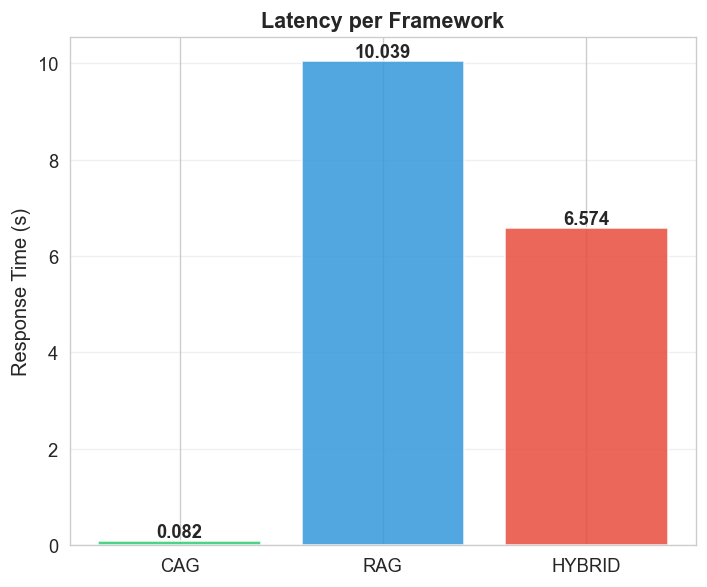

Saved: logs/framework_latency.png


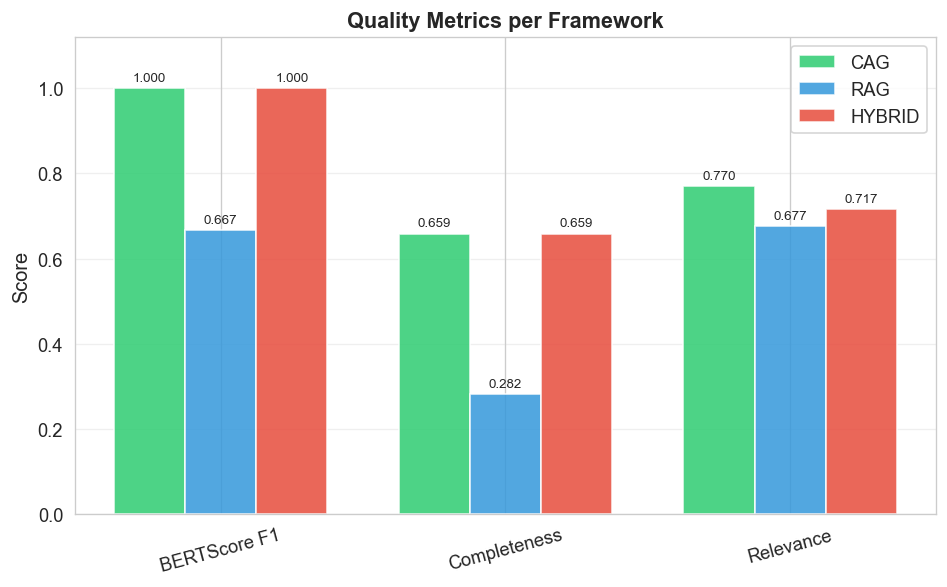

Saved: logs/framework_quality.png


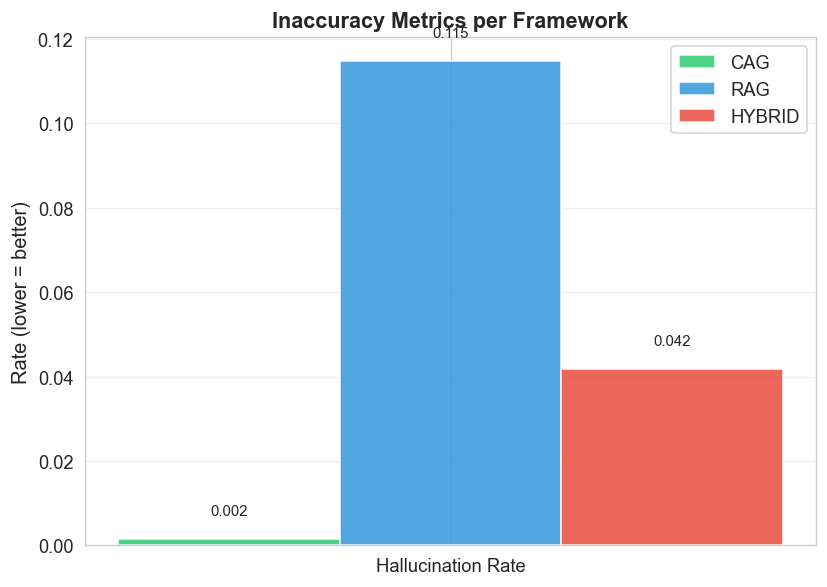

Saved: logs/framework_inaccuracy.png


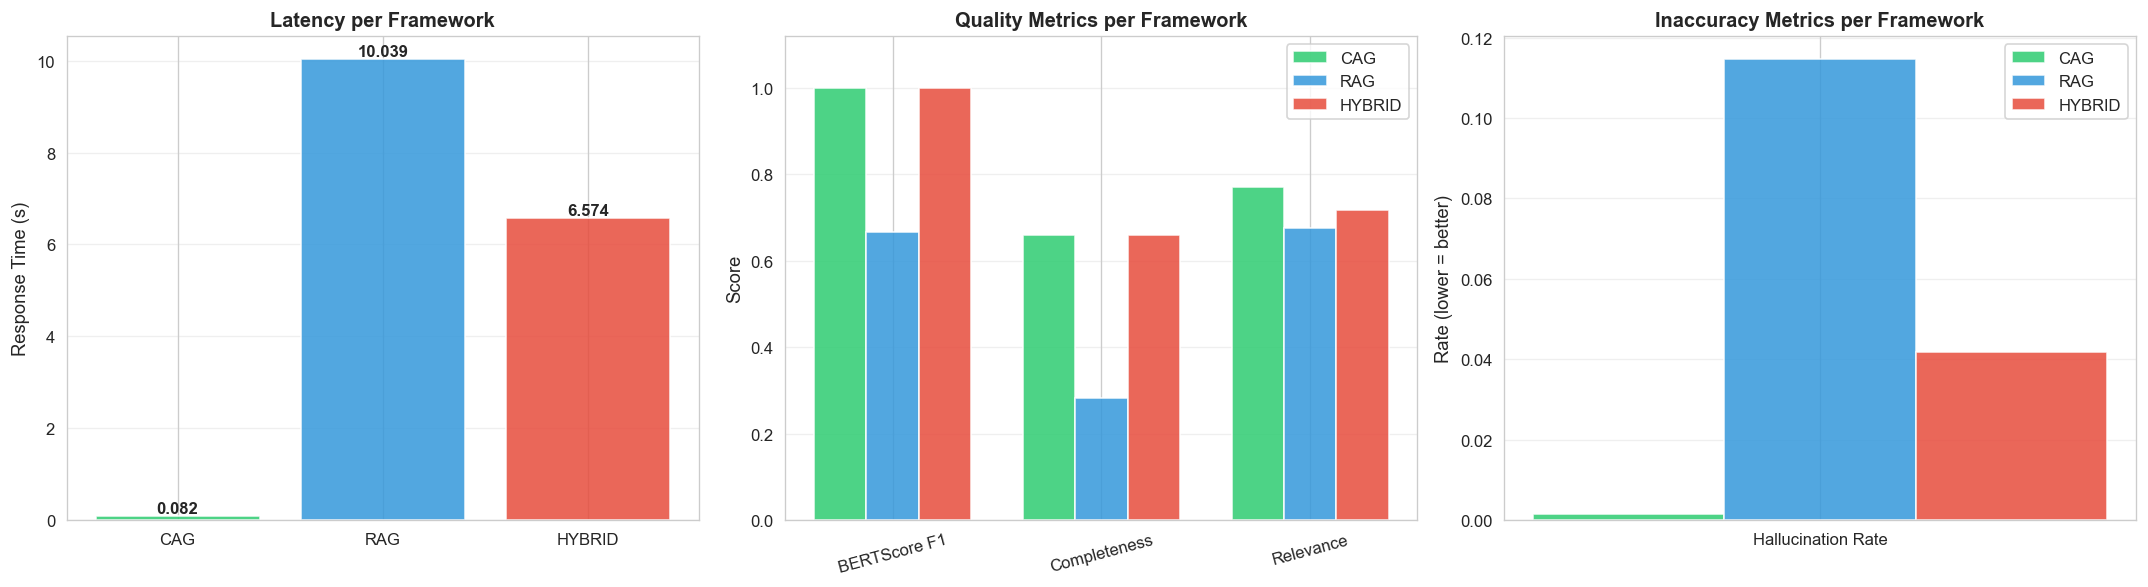

Saved: logs/framework_comparison.png (overview)


In [26]:
# [Cell 47]
# Per-Framework Visualization: CAG vs RAG vs Hybrid
# Setiap panel juga disimpan sebagai gambar mandiri (individual) untuk keperluan paper.

frameworks_available = [f for f in ['CAG', 'RAG', 'HYBRID'] if f in framework_metrics]
colors = {'CAG': '#2ecc71', 'RAG': '#3498db', 'HYBRID': '#e74c3c'}


def _safe(v):
    return 0.0 if v is None or (isinstance(v, float) and np.isnan(v)) else v


def _label(v):
    return "N/A" if v is None or (isinstance(v, float) and np.isnan(v)) else f"{v:.3f}"


width = 0.75 / max(len(frameworks_available), 1)

# ── 1. Latency per Framework (individual figure) ─────────────────────────
fig1, ax1 = plt.subplots(figsize=(6, 5))
times_raw = [framework_metrics[s]['time_avg'] for s in frameworks_available]
times = [_safe(v) for v in times_raw]
bars = ax1.bar(frameworks_available, times,
               color=[colors[s] for s in frameworks_available], alpha=0.85, edgecolor='white')
ax1.set_ylabel('Response Time (s)', fontsize=12)
ax1.set_title('Latency per Framework', fontsize=13, fontweight='bold')
ax1.tick_params(labelsize=11)
for bar, val in zip(bars, times_raw):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             _label(val), ha='center', va='bottom', fontsize=11, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)
fig1.tight_layout()
fig1.savefig('../logs/framework_latency.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: logs/framework_latency.png")

# ── 2. Quality Metrics per Framework (individual figure) ─────────────────
fig2, ax2 = plt.subplots(figsize=(8, 5))
quality_metrics = ['bert', 'comp', 'rel']
quality_labels  = ['BERTScore F1', 'Completeness', 'Relevance']
x_q = np.arange(len(quality_metrics))
for idx, fw in enumerate(frameworks_available):
    raw_vals = [framework_metrics[fw][m] for m in quality_metrics]
    vals = [_safe(v) for v in raw_vals]
    pos = x_q + (idx - (len(frameworks_available) - 1) / 2) * width
    bars2 = ax2.bar(pos, vals, width, label=fw, color=colors[fw], alpha=0.85,
                    edgecolor='white')
    for bar, val in zip(bars2, raw_vals):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 _label(val), ha='center', va='bottom', fontsize=8)
ax2.set_ylabel('Score', fontsize=12)
ax2.set_title('Quality Metrics per Framework', fontsize=13, fontweight='bold')
ax2.set_xticks(x_q)
ax2.set_xticklabels(quality_labels, rotation=15, fontsize=11)
ax2.tick_params(labelsize=11)
ax2.legend(fontsize=11)
ax2.set_ylim(0, 1.12)
ax2.grid(axis='y', alpha=0.3)
fig2.tight_layout()
fig2.savefig('../logs/framework_quality.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: logs/framework_quality.png")

# ── 3. Inaccuracy Metrics per Framework (individual figure) ──────────────
fig3, ax3 = plt.subplots(figsize=(7, 5))
inacc_metrics = ['hall']
inacc_labels  = ['Hallucination Rate']
x_i = np.arange(len(inacc_metrics))
for idx, fw in enumerate(frameworks_available):
    raw_vals = [framework_metrics[fw][m] for m in inacc_metrics]
    vals = [_safe(v) for v in raw_vals]
    pos = x_i + (idx - (len(frameworks_available) - 1) / 2) * width
    bars3 = ax3.bar(pos, vals, width, label=fw, color=colors[fw], alpha=0.85,
                    edgecolor='white')
    for bar, val in zip(bars3, raw_vals):
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 _label(val), ha='center', va='bottom', fontsize=9)
ax3.set_ylabel('Rate (lower = better)', fontsize=12)
ax3.set_title('Inaccuracy Metrics per Framework', fontsize=13, fontweight='bold')
ax3.set_xticks(x_i)
ax3.set_xticklabels(inacc_labels, fontsize=11)
ax3.tick_params(labelsize=11)
ax3.legend(fontsize=11)
ax3.grid(axis='y', alpha=0.3)
fig3.tight_layout()
fig3.savefig('../logs/framework_inaccuracy.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: logs/framework_inaccuracy.png")

# ── Combined overview (3-panel) ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# panel 1: latency
ax = axes[0]
bars = ax.bar(frameworks_available, times, color=[colors[s] for s in frameworks_available], alpha=0.85)
ax.set_ylabel('Response Time (s)', fontsize=11)
ax.set_title('Latency per Framework', fontsize=12, fontweight='bold')
ax.tick_params(labelsize=10)
for bar, val in zip(bars, times_raw):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            _label(val), ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# panel 2: quality
ax = axes[1]
for idx, fw in enumerate(frameworks_available):
    raw_vals = [framework_metrics[fw][m] for m in quality_metrics]
    vals = [_safe(v) for v in raw_vals]
    pos = x_q + (idx - (len(frameworks_available) - 1) / 2) * width
    ax.bar(pos, vals, width, label=fw, color=colors[fw], alpha=0.85)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Quality Metrics per Framework', fontsize=12, fontweight='bold')
ax.set_xticks(x_q)
ax.set_xticklabels(quality_labels, rotation=15, fontsize=10)
ax.legend(fontsize=10)
ax.set_ylim(0, 1.12)
ax.grid(axis='y', alpha=0.3)

# panel 3: inaccuracy
ax = axes[2]
for idx, fw in enumerate(frameworks_available):
    raw_vals = [framework_metrics[fw][m] for m in inacc_metrics]
    vals = [_safe(v) for v in raw_vals]
    pos = x_i + (idx - (len(frameworks_available) - 1) / 2) * width
    ax.bar(pos, vals, width, label=fw, color=colors[fw], alpha=0.85)
ax.set_ylabel('Rate (lower = better)', fontsize=11)
ax.set_title('Inaccuracy Metrics per Framework', fontsize=12, fontweight='bold')
ax.set_xticks(x_i)
ax.set_xticklabels(inacc_labels, fontsize=10)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../logs/framework_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: logs/framework_comparison.png (overview)")


## [Cell 48] 1. Retrieval Latency Metrics (CAG vs RAG vs Hybrid)

Metrik ini digunakan untuk mengukur efisiensi performa waktu sistem. Terdiri dari:
* **Response Time Avg (detik):** Rata-rata waktu respons sistem.
* **Cache Hit Rate (CHR) (%):** Persentase kueri yang berhasil dilayani oleh cache.
* **Speedup Factor (x):** Faktor percepatan sistem dibandingkan dengan baseline RAG.

LATENCY SUMMARY — CAG vs RAG vs HYBRID
  RAG avg time     : 10.039s ± 5.790s
  CAG avg time     : 0.082s ± 0.513s
  Speedup (RAG/CAG): 122.03x
  Hybrid avg time  : 6.574s ± 7.971s
  Speedup (RAG/Hybrid): 1.53x


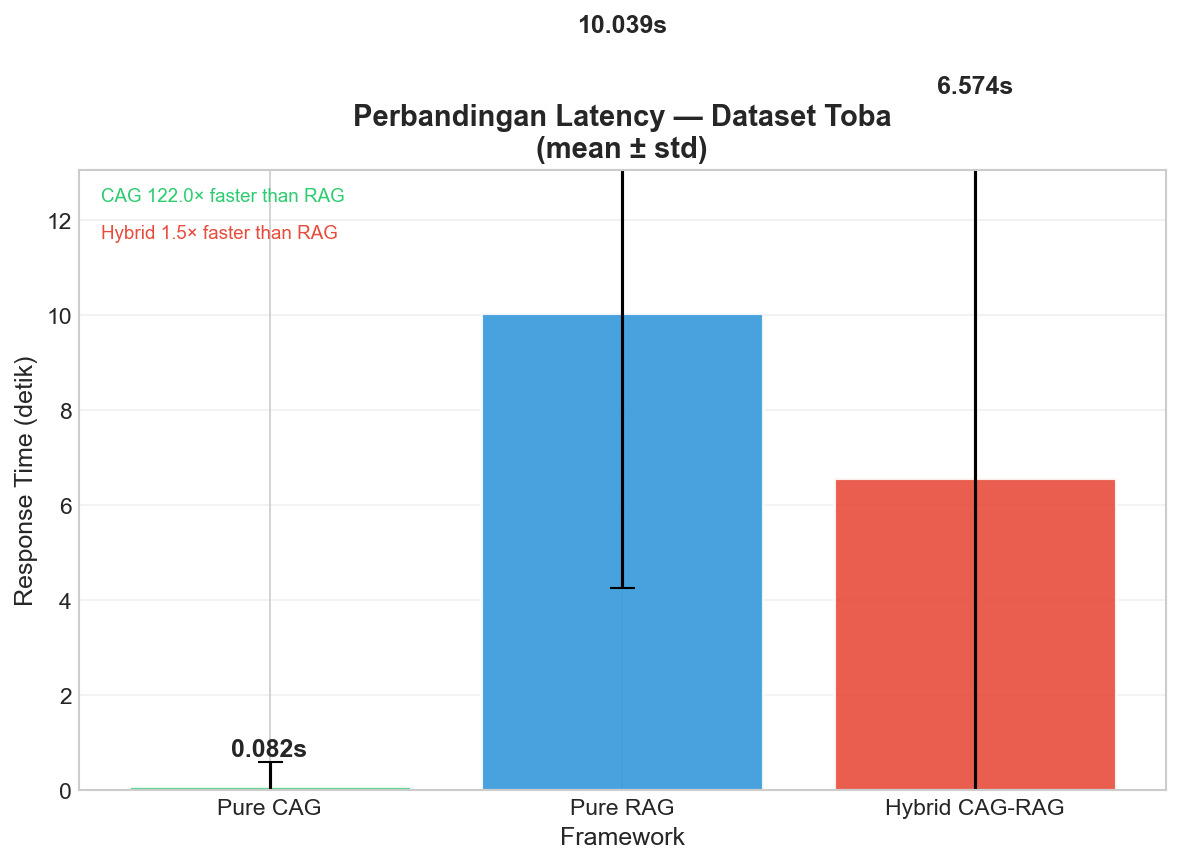

✅ Saved: logs/thesis_charts/toba_latency.png


In [27]:
# [Cell 49]
# LATENCY ANALYSIS — Framework Comparison (CAG vs RAG vs Hybrid)
# Bar Chart untuk Skripsi

import matplotlib.pyplot as plt
import numpy as np

# Setup style untuk publikasi ilmiah
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 300,
    'font.size': 11, 'axes.titlesize': 14, 'axes.labelsize': 12,
})

# Colors dan Labels
COLORS = {'CAG': '#2ecc71', 'RAG': '#3498db', 'HYBRID': '#e74c3c'}
LABELS = {'CAG': 'Pure CAG', 'RAG': 'Pure RAG', 'HYBRID': 'Hybrid CAG-RAG'}

rag_times     = rag_m['_time']
cag_times     = pure_cag_m['_time'] if pure_cag_m else []
hybrid_times  = cag_m['_time'] if cag_m else []

speedup_cag    = (rag_m['time_avg'] / pure_cag_m['time_avg']) if (pure_cag_m and pure_cag_m['time_avg'] > 0) else None
speedup_hybrid = (rag_m['time_avg'] / cag_m['time_avg']) if (cag_m and cag_m['time_avg'] > 0) else None

print("=" * 65)
print("LATENCY SUMMARY — CAG vs RAG vs HYBRID")
print("=" * 65)
print(f"  RAG avg time     : {rag_m['time_avg']:.3f}s ± {rag_m['time_std']:.3f}s")
if pure_cag_m:
    print(f"  CAG avg time     : {pure_cag_m['time_avg']:.3f}s ± {pure_cag_m['time_std']:.3f}s")
    print(f"  Speedup (RAG/CAG): {speedup_cag:.2f}x" if speedup_cag else "  Speedup (RAG/CAG): N/A")
if cag_m:
    print(f"  Hybrid avg time  : {cag_m['time_avg']:.3f}s ± {cag_m['time_std']:.3f}s")
    print(f"  Speedup (RAG/Hybrid): {speedup_hybrid:.2f}x" if speedup_hybrid else "  Speedup (RAG/Hybrid): N/A")
print("=" * 65)

# ============================================================================
# BAR CHART: Perbandingan Latency (Response Time) - Thesis Ready
# ============================================================================
os.makedirs('../logs/thesis_charts', exist_ok=True)

# Prepare data
frameworks, means, stds, colors_list = [], [], [], []
if pure_cag_m:
    frameworks.append('CAG')
    means.append(float(pure_cag_m['time_avg']))
    stds.append(float(pure_cag_m['time_std']))
    colors_list.append(COLORS['CAG'])
frameworks.append('RAG')
means.append(float(rag_m['time_avg']))
stds.append(float(rag_m['time_std']))
colors_list.append(COLORS['RAG'])
if cag_m:
    frameworks.append('HYBRID')
    means.append(float(cag_m['time_avg']))
    stds.append(float(cag_m['time_std']))
    colors_list.append(COLORS['HYBRID'])

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(
    [LABELS.get(f, f) for f in frameworks], means,
    color=colors_list,
    yerr=stds, capsize=6,
    edgecolor='white', linewidth=1.5, alpha=0.9
)

# Add value labels
for bar, val, std in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.02,
            f'{val:.3f}s', ha='center', va='bottom', fontweight='bold', fontsize=12)

ax.set_xlabel('Framework', fontsize=12)
ax.set_ylabel('Response Time (detik)', fontsize=12)
ax.set_title('Perbandingan Latency — Dataset Toba\n(mean ± std)', fontsize=14, fontweight='bold')
ax.set_ylim(0, max(means) * 1.3)
ax.grid(axis='y', alpha=0.3)

# Add speedup annotation
if speedup_cag and speedup_hybrid:
    ax.annotate(f'CAG {speedup_cag:.1f}× faster than RAG', 
                xy=(0.02, 0.95), xycoords='axes fraction', fontsize=9, color='#2ecc71')
    ax.annotate(f'Hybrid {speedup_hybrid:.1f}× faster than RAG', 
                xy=(0.02, 0.89), xycoords='axes fraction', fontsize=9, color='#e74c3c')

plt.tight_layout()
plt.savefig('../logs/thesis_charts/toba_latency.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig('../logs/avg_response_time_frameworks.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: logs/thesis_charts/toba_latency.png")

## [Cell 50] Retrieval Inaccuracy Metrics (CAG vs RAG vs Hybrid)

Sesi ini menampilkan metrik Retrieval Inaccuracy sesuai daftar evaluasi utama. Semua metrik berikut tetap dihitung pada pipeline evaluasi:
- Relevance Score
- Exact Match (EM)
- Effective Information Rate (EIR)
- RAG Recall
- BERTScore F1
- Completeness
- Hallucination Rate


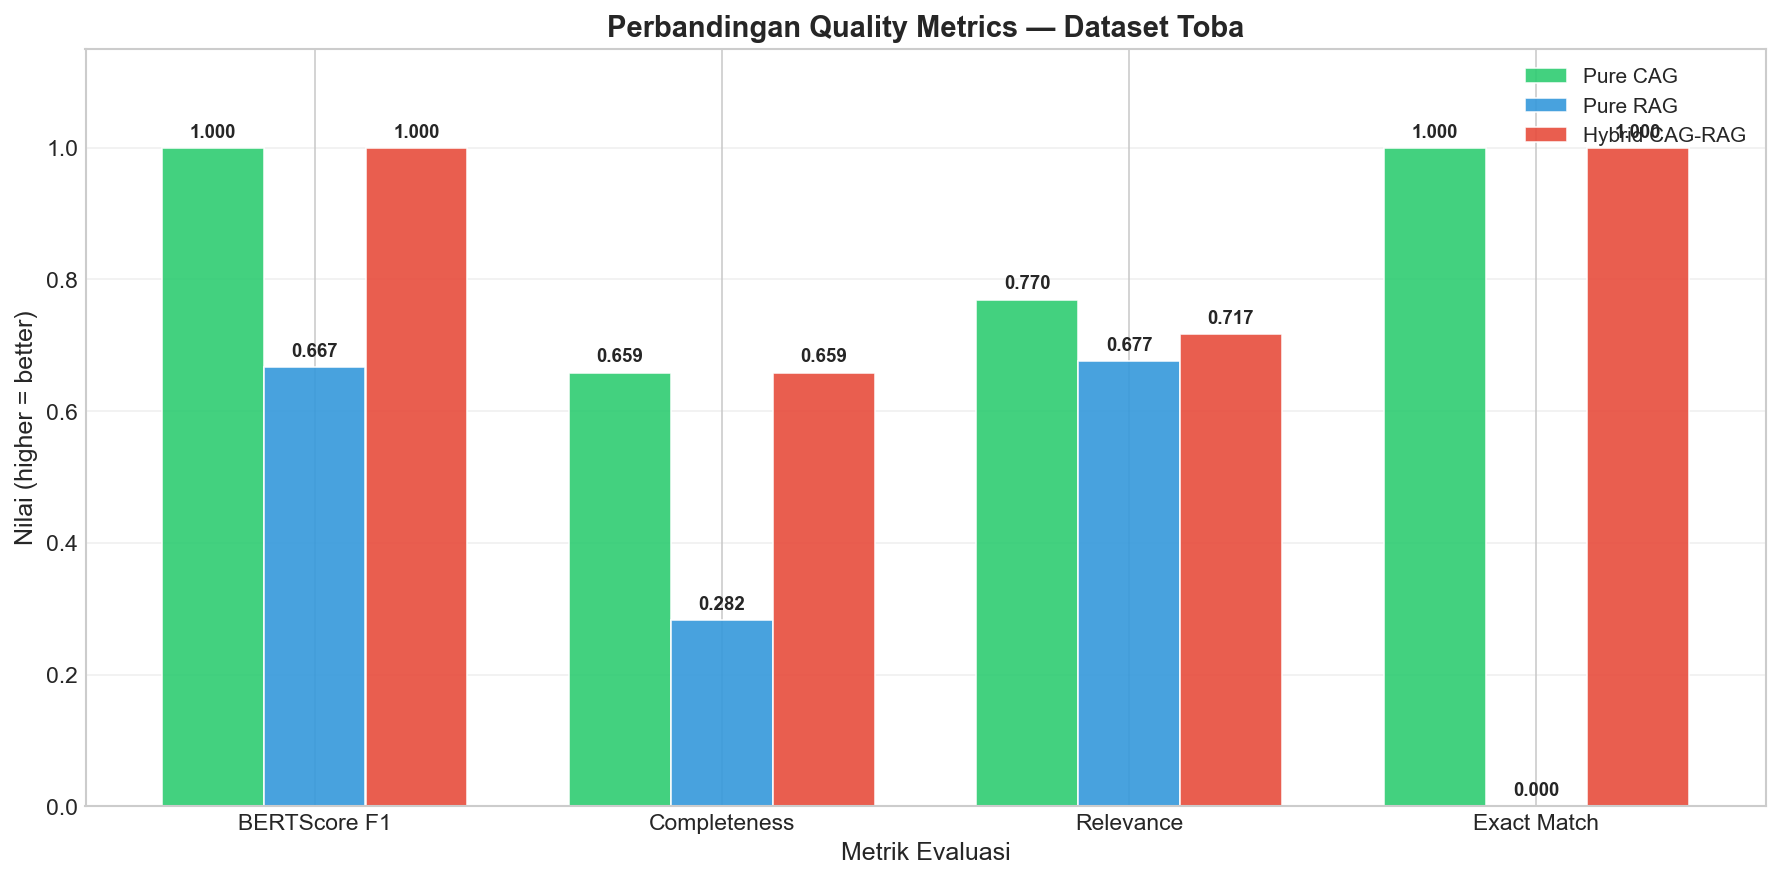

✅ Saved: logs/thesis_charts/toba_quality_metrics.png


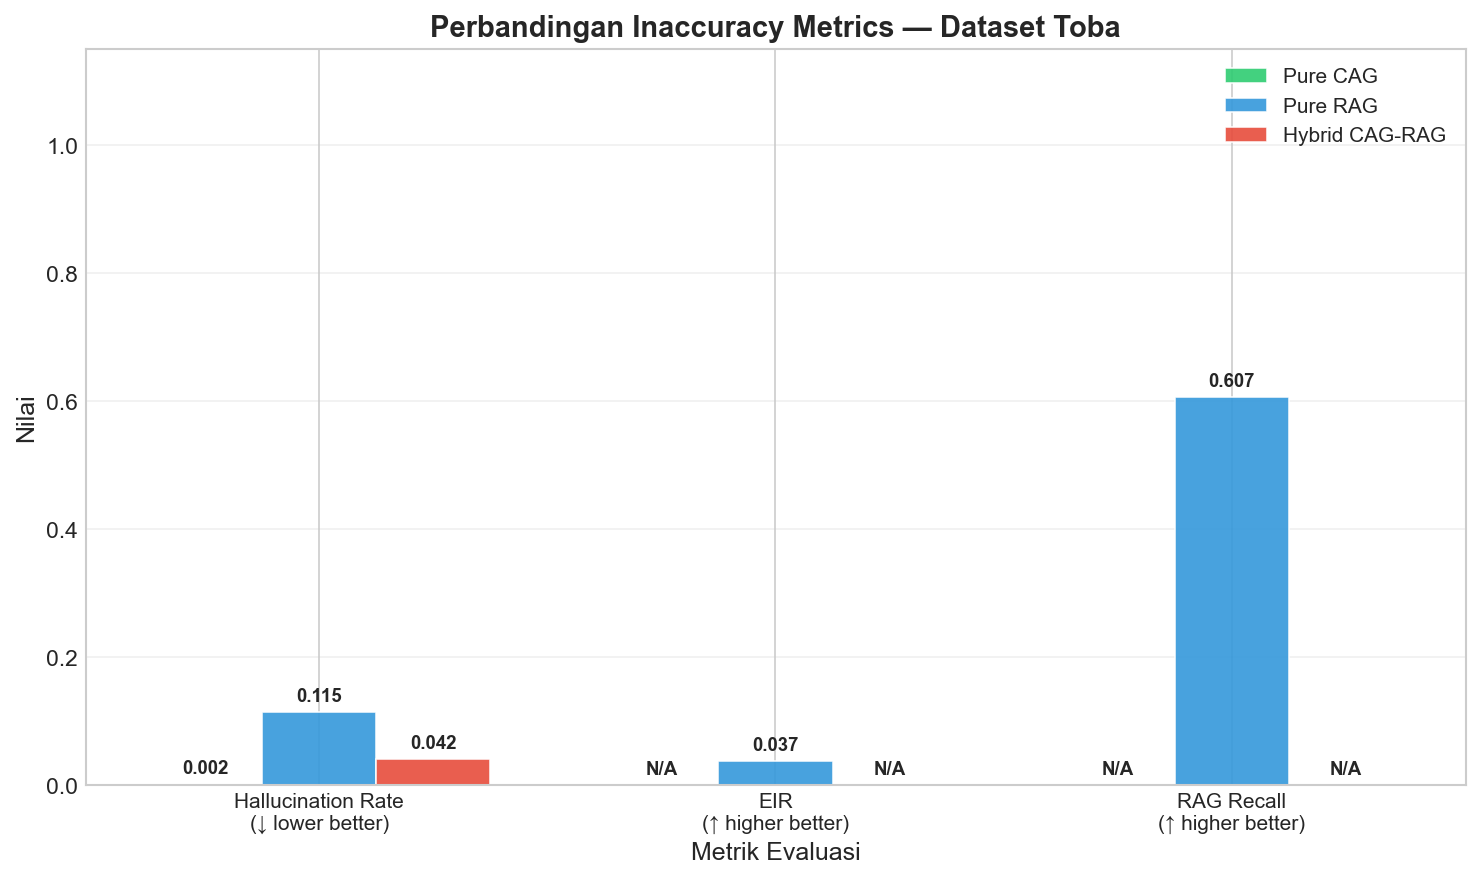

✅ Saved: logs/thesis_charts/toba_inaccuracy_metrics.png


In [28]:
# [Cell 51]
# RETRIEVAL INACCURACY VISUALIZATION — Framework Comparison (Thesis Ready)
# Bar Chart profesional untuk skripsi

framework_metrics = {
    'CAG': pure_cag_m,
    'RAG': rag_m,
    'HYBRID': cag_m,
}
frameworks = [f for f in ['CAG', 'RAG', 'HYBRID'] if framework_metrics.get(f)]
COLORS = {'CAG': '#2ecc71', 'RAG': '#3498db', 'HYBRID': '#e74c3c'}
LABELS = {'CAG': 'Pure CAG', 'RAG': 'Pure RAG', 'HYBRID': 'Hybrid CAG-RAG'}
width = 0.25

def _safe(v):
    return 0.0 if v is None or (isinstance(v, float) and np.isnan(v)) else v

def _label(v):
    return "N/A" if v is None or (isinstance(v, float) and np.isnan(v)) else f"{v:.3f}"

# ============================================================================
# BAR CHART: Quality Metrics (BERTScore, Completeness, Relevance, EM)
# ============================================================================
quality_keys = ['bert', 'comp', 'rel', 'em']
quality_labels = ['BERTScore F1', 'Completeness', 'Relevance', 'Exact Match']

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(quality_keys))

for idx, fw in enumerate(frameworks):
    raw_vals = [framework_metrics[fw].get(k) for k in quality_keys]
    vals = [_safe(v) for v in raw_vals]
    offset = (idx - (len(frameworks) - 1) / 2) * width
    bars = ax.bar(x + offset, vals, width, label=LABELS[fw], color=COLORS[fw], 
                  edgecolor='white', linewidth=0.8, alpha=0.9)
    for bar, v_raw in zip(bars, raw_vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                _label(v_raw), ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(quality_labels, fontsize=11)
ax.set_xlabel('Metrik Evaluasi', fontsize=12)
ax.set_ylabel('Nilai (higher = better)', fontsize=12)
ax.set_title('Perbandingan Quality Metrics — Dataset Toba', fontsize=14, fontweight='bold')
ax.set_ylim(0, 1.15)
ax.legend(loc='upper right', fontsize=10, framealpha=0.9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../logs/thesis_charts/toba_quality_metrics.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig('../logs/retrieval_inaccuracy_metrics_part1.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: logs/thesis_charts/toba_quality_metrics.png")

# ============================================================================
# BAR CHART: Inaccuracy Metrics (Hallucination, EIR, Recall)
# ============================================================================
inaccuracy_keys = ['hall', 'eir', 'recall']
inaccuracy_labels = ['Hallucination Rate\n(↓ lower better)', 'EIR\n(↑ higher better)', 'RAG Recall\n(↑ higher better)']

fig2, ax2 = plt.subplots(figsize=(10, 6))
x2 = np.arange(len(inaccuracy_keys))

for idx, fw in enumerate(frameworks):
    raw_vals = [framework_metrics[fw].get(k) for k in inaccuracy_keys]
    vals = [_safe(v) for v in raw_vals]
    offset = (idx - (len(frameworks) - 1) / 2) * width
    bars = ax2.bar(x2 + offset, vals, width, label=LABELS[fw], color=COLORS[fw],
                   edgecolor='white', linewidth=0.8, alpha=0.9)
    for bar, v_raw in zip(bars, raw_vals):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 _label(v_raw), ha='center', va='bottom', fontsize=9, fontweight='bold')

ax2.set_xticks(x2)
ax2.set_xticklabels(inaccuracy_labels, fontsize=10)
ax2.set_xlabel('Metrik Evaluasi', fontsize=12)
ax2.set_ylabel('Nilai', fontsize=12)
ax2.set_title('Perbandingan Inaccuracy Metrics — Dataset Toba', fontsize=14, fontweight='bold')
ax2.set_ylim(0, 1.15)
ax2.legend(loc='upper right', fontsize=10, framealpha=0.9)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../logs/thesis_charts/toba_inaccuracy_metrics.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig('../logs/retrieval_inaccuracy_metrics_part2.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: logs/thesis_charts/toba_inaccuracy_metrics.png")

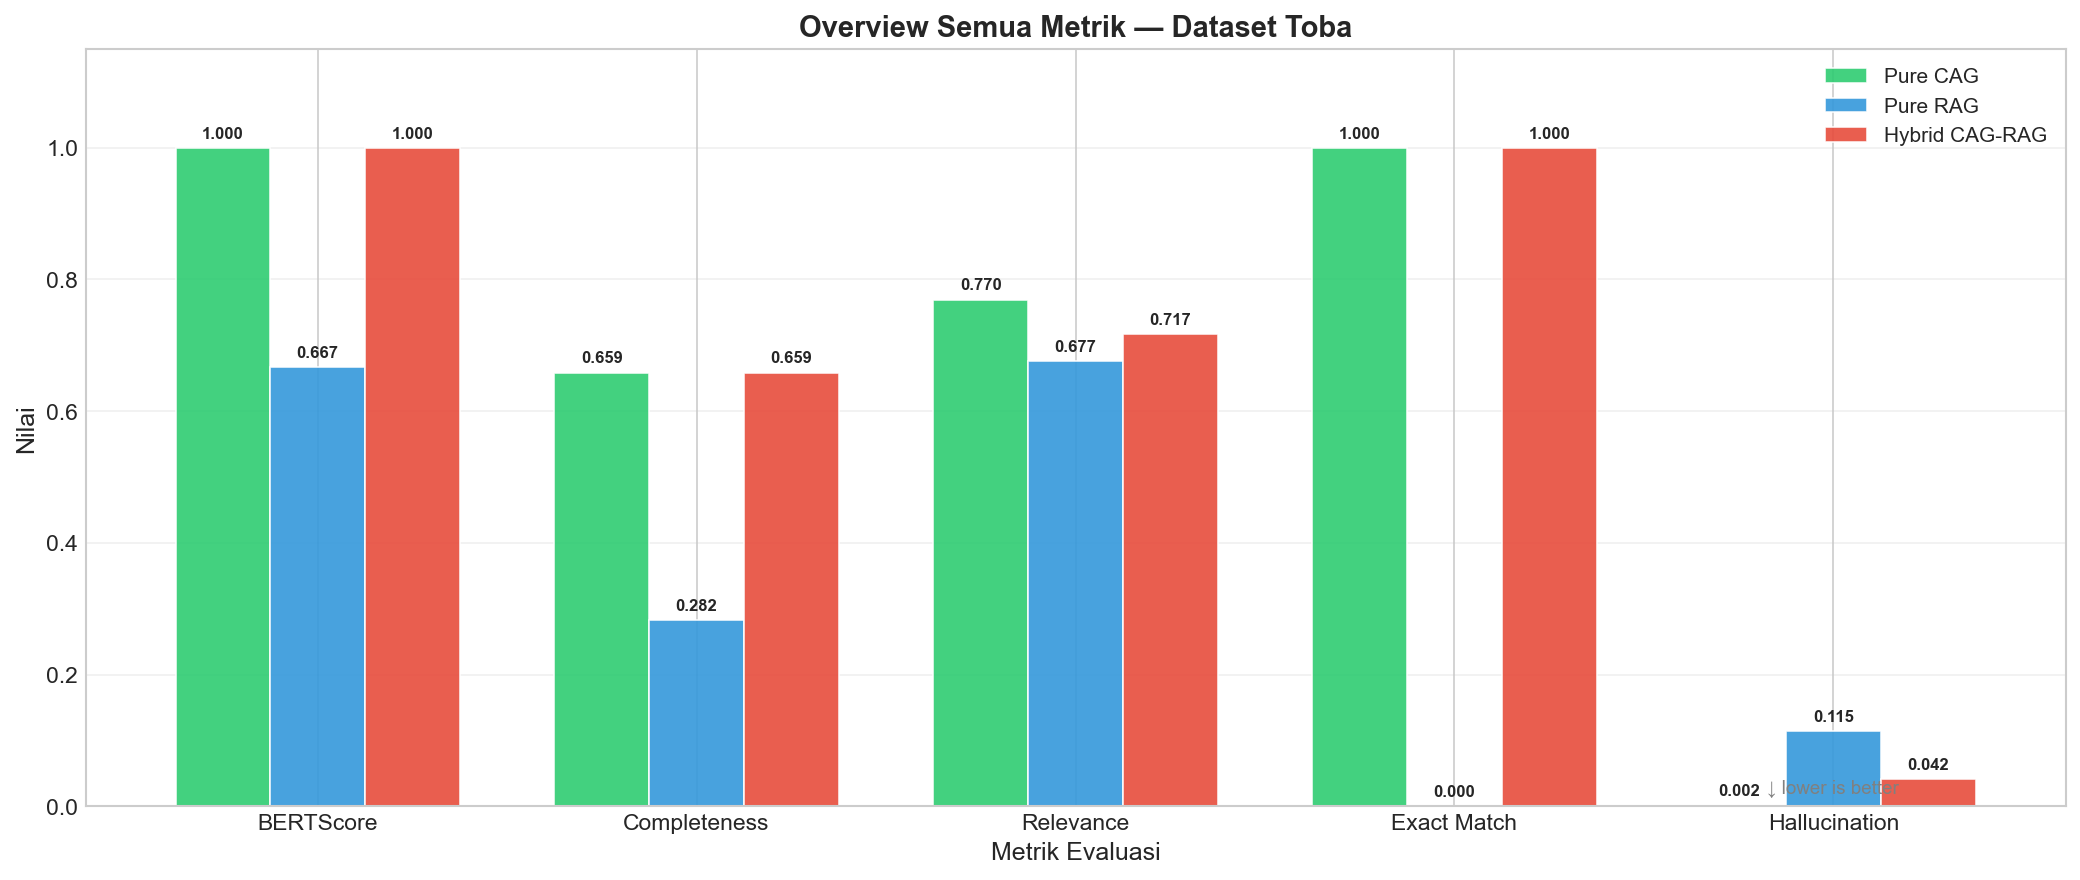

✅ Saved: logs/thesis_charts/toba_all_metrics.png

📊 Toba results stored in TOBA_RESULTS


In [29]:
# [Cell 52]
# ============================================================================
# OVERVIEW: Semua Metrik dalam Satu Chart (Thesis Ready)
# ============================================================================

all_metrics = ['bert', 'comp', 'rel', 'em', 'hall']
all_labels = ['BERTScore', 'Completeness', 'Relevance', 'Exact Match', 'Hallucination']

fig_all, ax_all = plt.subplots(figsize=(14, 6))
x = np.arange(len(all_metrics))

for idx, fw in enumerate(frameworks):
    raw_vals = [framework_metrics[fw].get(k) for k in all_metrics]
    vals = [_safe(v) for v in raw_vals]
    offset = (idx - (len(frameworks) - 1) / 2) * width
    bars = ax_all.bar(x + offset, vals, width, label=LABELS[fw], color=COLORS[fw],
                      edgecolor='white', linewidth=0.8, alpha=0.9)
    for bar, v_raw in zip(bars, raw_vals):
        ax_all.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    _label(v_raw), ha='center', va='bottom', fontsize=8, fontweight='bold')

ax_all.set_xticks(x)
ax_all.set_xticklabels(all_labels, fontsize=11)
ax_all.set_xlabel('Metrik Evaluasi', fontsize=12)
ax_all.set_ylabel('Nilai', fontsize=12)
ax_all.set_title('Overview Semua Metrik — Dataset Toba', fontsize=14, fontweight='bold')
ax_all.set_ylim(0, 1.15)
ax_all.legend(loc='upper right', fontsize=10, framealpha=0.9)
ax_all.grid(axis='y', alpha=0.3)

# Annotation untuk hallucination
ax_all.annotate('↓ lower is better', xy=(4, 0.02), fontsize=9, ha='center', color='gray')

plt.tight_layout()
plt.savefig('../logs/thesis_charts/toba_all_metrics.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig('../logs/retrieval_inaccuracy_metrics_part3.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: logs/thesis_charts/toba_all_metrics.png")

# Store results for cross-dataset comparison
TOBA_RESULTS = {fw: {k: v for k, v in framework_metrics[fw].items() 
                     if not k.startswith('_') and k != 'per_query'} 
                for fw in frameworks if framework_metrics[fw]}
print(f"\n📊 Toba results stored in TOBA_RESULTS")

## [Cell 53] 📊 1. Visualisasi Evaluasi - Pure CAG

Bagian ini menampilkan performa sistem **Pure CAG** (hanya menggunakan pencarian berbasis cache tanpa fallback ke RAG).

### A. Retrieval Latency Metrics (Pure CAG)
Mengukur rata-rata waktu respons dan Cache Hit Rate (CHR) dari Pure CAG.

### B. Retrieval Inaccuracy Metrics (Pure CAG)
Mengukur kualitas jawaban dan ketepatan informasi yang dihasilkan oleh Pure CAG.


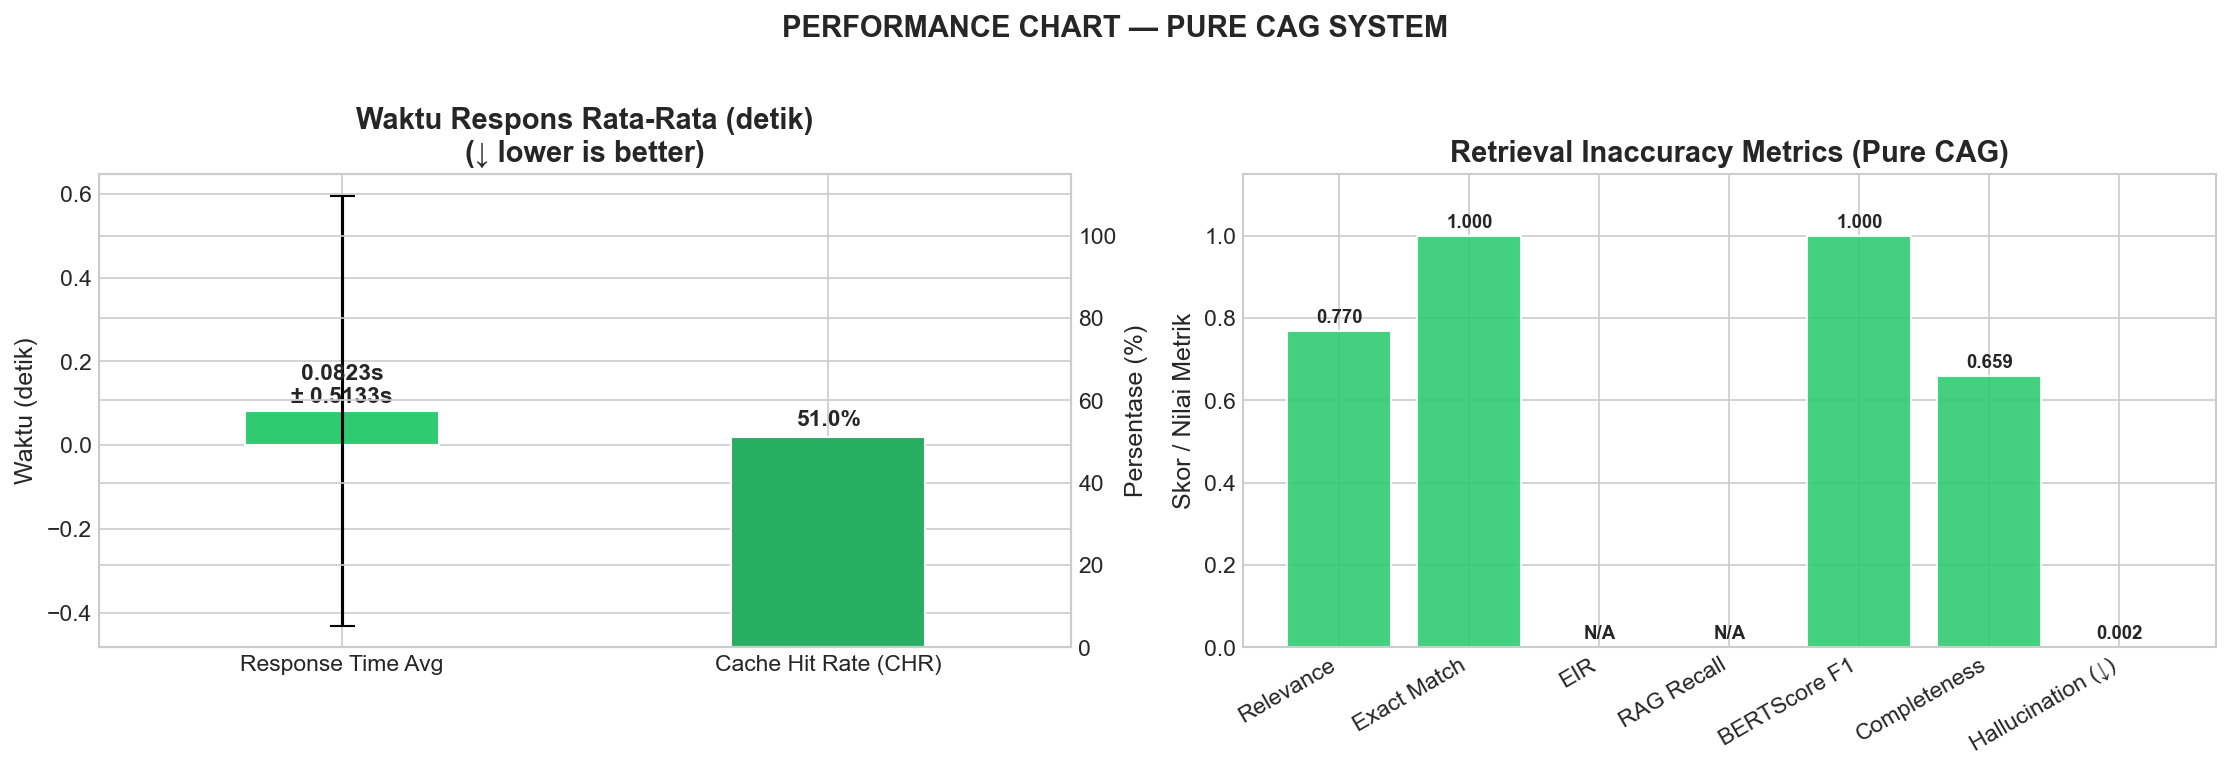

In [30]:
# [Cell 54]
# ============================================================================
# VISUALISASI PURE CAG (LATENCY & INACCURACY)
# ============================================================================
import matplotlib.pyplot as plt
import numpy as np

# Setup Style
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# 1. Latency & CHR Subplots
latency_val = float(pure_cag_m['time_avg'])
latency_std = float(pure_cag_m['time_std'])
chr_val = float(pure_cag_m['chr']) * 100

# Plot Latency
ax1.bar(['Response Time Avg'], [latency_val], yerr=[latency_std], capsize=6, color='#2ecc71', width=0.4, edgecolor='white')
ax1.text(0, latency_val + 0.01, f'{latency_val:.4f}s\n± {latency_std:.4f}s', ha='center', va='bottom', fontweight='bold')
ax1.set_ylabel('Waktu (detik)')
ax1.set_title('Waktu Respons Rata-Rata (detik)\n(↓ lower is better)', fontweight='bold')

# Plot CHR
ax1_twin = ax1.twinx() # Gunakan sumbu y kedua untuk persentase CHR
ax1_twin.bar(['Cache Hit Rate (CHR)'], [chr_val], color='#27ae60', width=0.4, edgecolor='white')
ax1_twin.text(1, chr_val + 2, f'{chr_val:.1f}%', ha='center', va='bottom', fontweight='bold')
ax1_twin.set_ylabel('Persentase (%)')
ax1_twin.set_ylim(0, 115)
ax1.set_xlim(-0.5, 1.5)

# 2. Inaccuracy Metrics (7 Metrik)
inaccuracy_keys = ['rel', 'em', 'eir', 'recall', 'bert', 'comp', 'hall']
inaccuracy_labels = ['Relevance', 'Exact Match', 'EIR', 'RAG Recall', 'BERTScore F1', 'Completeness', 'Hallucination (↓)']
raw_vals = [pure_cag_m.get(k) for k in inaccuracy_keys]
vals = [0.0 if v is None or (isinstance(v, float) and np.isnan(v)) else v for v in raw_vals]

bars = ax2.bar(inaccuracy_labels, vals, color='#2ecc71', edgecolor='white', alpha=0.9)
for bar, v_raw in zip(bars, raw_vals):
    lbl = "N/A" if v_raw is None or (isinstance(v_raw, float) and np.isnan(v_raw)) else f"{v_raw:.3f}"
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, lbl, ha='center', va='bottom', fontsize=9, fontweight='bold')

ax2.set_title('Retrieval Inaccuracy Metrics (Pure CAG)', fontweight='bold')
ax2.set_ylabel('Skor / Nilai Metrik')
ax2.set_ylim(0, 1.15)
ax2.set_xticklabels(inaccuracy_labels, rotation=30, ha='right')

plt.suptitle('PERFORMANCE CHART — PURE CAG SYSTEM', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../logs/thesis_charts/pure_cag_performance.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


## [Cell 55] 📊 2. Visualisasi Evaluasi - Pure RAG

Bagian ini menampilkan performa sistem **Pure RAG** (pencarian dokumen berbasis vector database dan generasi respons, tanpa cache).

### A. Retrieval Latency Metrics (Pure RAG)
Mengukur rata-rata waktu respons dan Cache Hit Rate (CHR) dari Pure RAG.

### B. Retrieval Inaccuracy Metrics (Pure RAG)
Mengukur kualitas jawaban dan ketepatan informasi yang dihasilkan oleh Pure RAG.


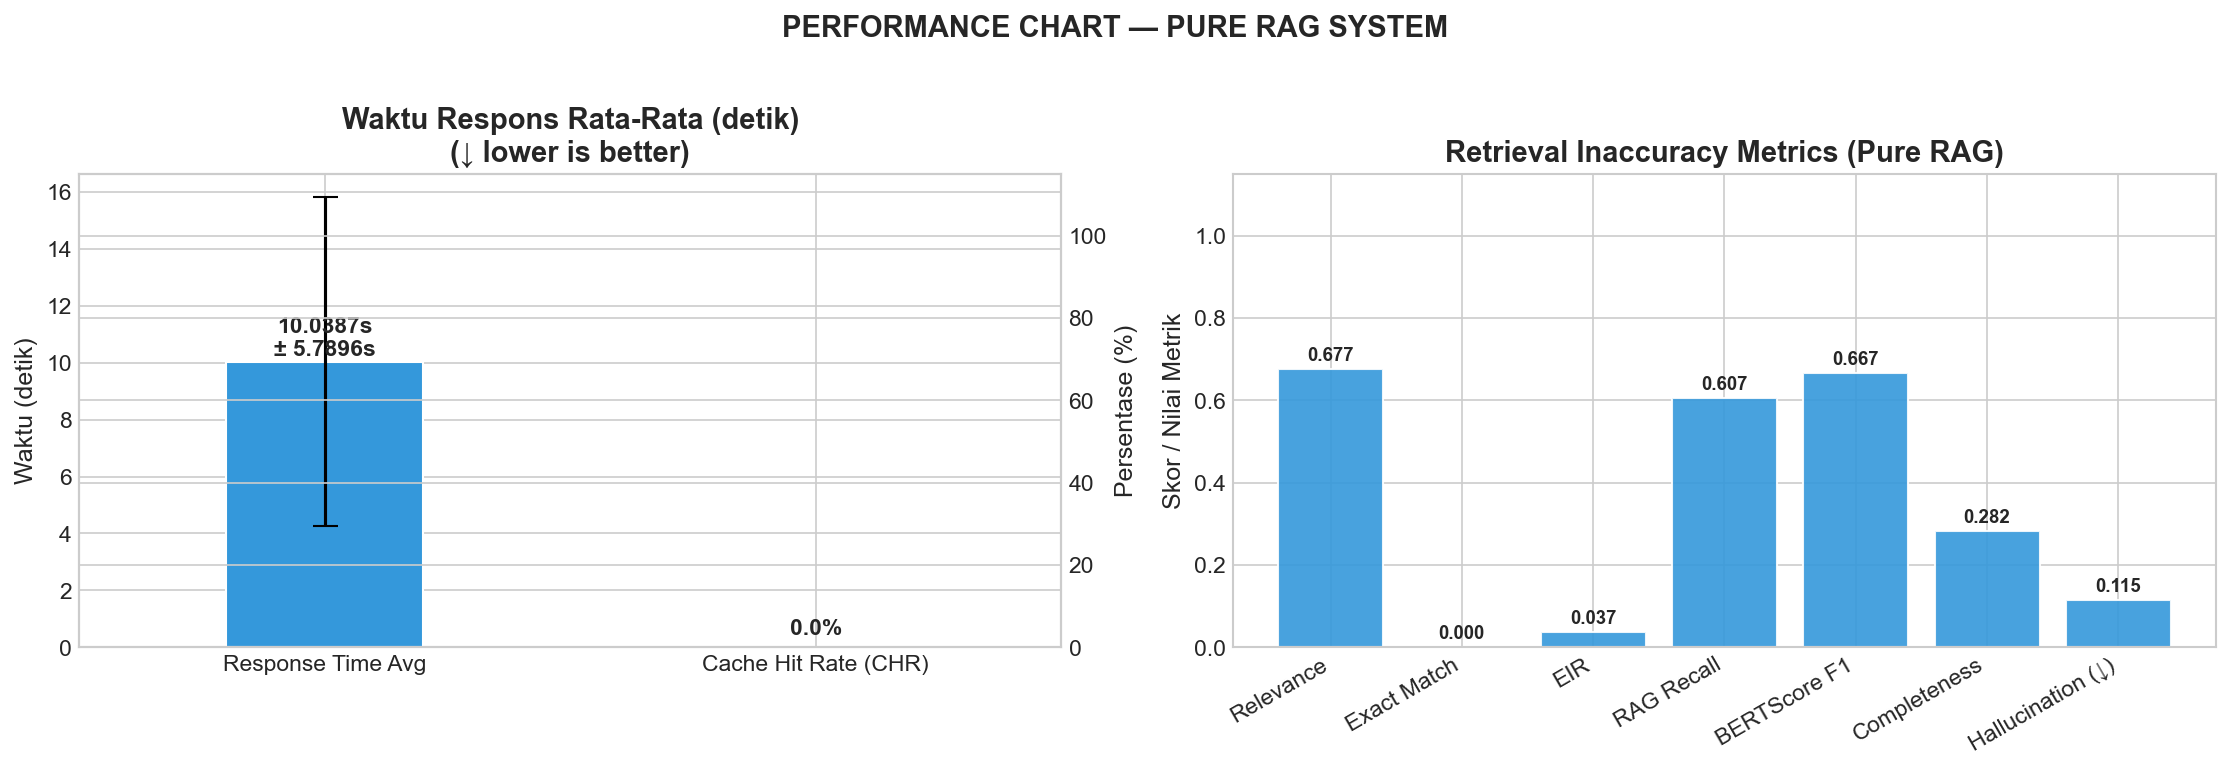

In [31]:
# [Cell 56]
# ============================================================================
# VISUALISASI PURE RAG (LATENCY & INACCURACY)
# ============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# 1. Latency & CHR Subplots
latency_val = float(rag_m['time_avg'])
latency_std = float(rag_m['time_std'])
chr_val = float(rag_m['chr']) * 100

# Plot Latency
ax1.bar(['Response Time Avg'], [latency_val], yerr=[latency_std], capsize=6, color='#3498db', width=0.4, edgecolor='white')
ax1.text(0, latency_val + 0.05, f'{latency_val:.4f}s\n± {latency_std:.4f}s', ha='center', va='bottom', fontweight='bold')
ax1.set_ylabel('Waktu (detik)')
ax1.set_title('Waktu Respons Rata-Rata (detik)\n(↓ lower is better)', fontweight='bold')

# Plot CHR
ax1_twin = ax1.twinx()
ax1_twin.bar(['Cache Hit Rate (CHR)'], [chr_val], color='#2980b9', width=0.4, edgecolor='white')
ax1_twin.text(1, chr_val + 2, f'{chr_val:.1f}%', ha='center', va='bottom', fontweight='bold')
ax1_twin.set_ylabel('Persentase (%)')
ax1_twin.set_ylim(0, 115)
ax1.set_xlim(-0.5, 1.5)

# 2. Inaccuracy Metrics (7 Metrik)
raw_vals = [rag_m.get(k) for k in inaccuracy_keys]
vals = [0.0 if v is None or (isinstance(v, float) and np.isnan(v)) else v for v in raw_vals]

bars = ax2.bar(inaccuracy_labels, vals, color='#3498db', edgecolor='white', alpha=0.9)
for bar, v_raw in zip(bars, raw_vals):
    lbl = "N/A" if v_raw is None or (isinstance(v_raw, float) and np.isnan(v_raw)) else f"{v_raw:.3f}"
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, lbl, ha='center', va='bottom', fontsize=9, fontweight='bold')

ax2.set_title('Retrieval Inaccuracy Metrics (Pure RAG)', fontweight='bold')
ax2.set_ylabel('Skor / Nilai Metrik')
ax2.set_ylim(0, 1.15)
ax2.set_xticklabels(inaccuracy_labels, rotation=30, ha='right')

plt.suptitle('PERFORMANCE CHART — PURE RAG SYSTEM', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../logs/thesis_charts/pure_rag_performance.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


## [Cell 57] 📊 3. Visualisasi Evaluasi - Hybrid CAG-RAG

Bagian ini menampilkan performa sistem **Hybrid CAG-RAG** (pencarian berbasis cache terlebih dahulu, lalu beralih ke RAG jika terjadi cache-miss).

### A. Retrieval Latency Metrics (Hybrid CAG-RAG)
Mengukur rata-rata waktu respons dan Cache Hit Rate (CHR) dari Hybrid CAG-RAG.

### B. Retrieval Inaccuracy Metrics (Hybrid CAG-RAG)
Mengukur kualitas jawaban dan ketepatan informasi yang dihasilkan oleh Hybrid CAG-RAG.


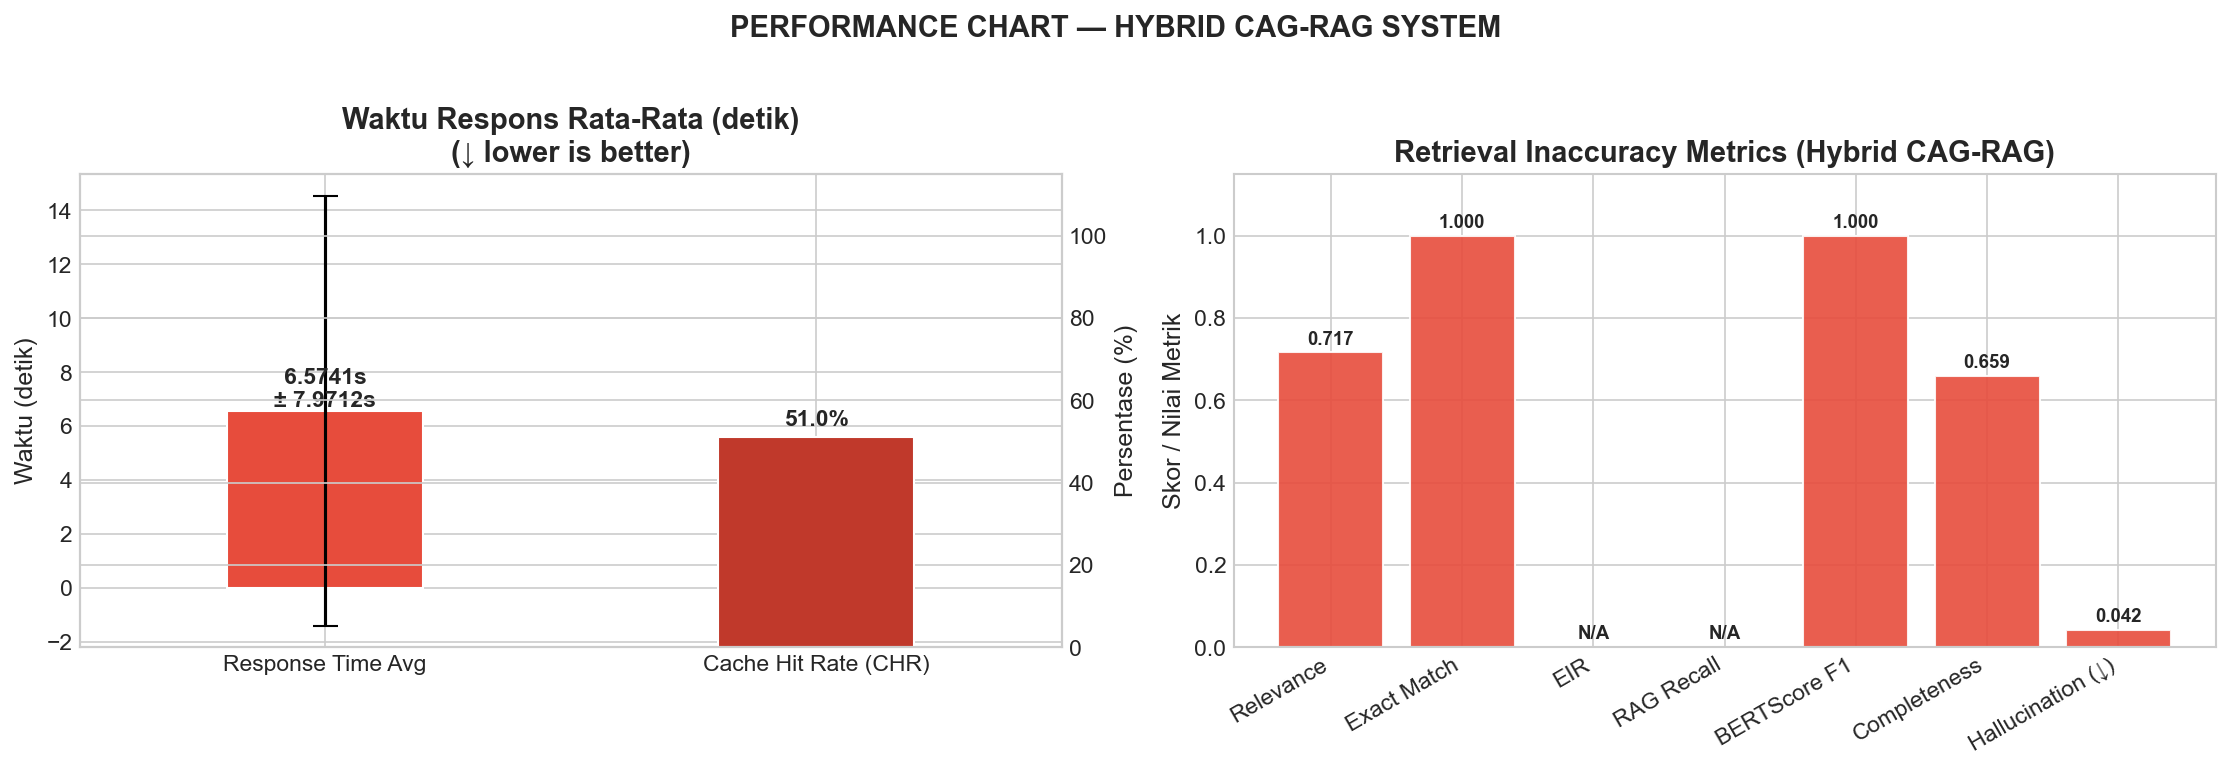

In [32]:
# [Cell 58]
# ============================================================================
# VISUALISASI HYBRID CAG-RAG (LATENCY & INACCURACY)
# ============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# 1. Latency & CHR Subplots
latency_val = float(cag_m['time_avg'])
latency_std = float(cag_m['time_std'])
chr_val = float(cag_m['chr']) * 100

# Plot Latency
ax1.bar(['Response Time Avg'], [latency_val], yerr=[latency_std], capsize=6, color='#e74c3c', width=0.4, edgecolor='white')
ax1.text(0, latency_val + 0.01, f'{latency_val:.4f}s\n± {latency_std:.4f}s', ha='center', va='bottom', fontweight='bold')
ax1.set_ylabel('Waktu (detik)')
ax1.set_title('Waktu Respons Rata-Rata (detik)\n(↓ lower is better)', fontweight='bold')

# Plot CHR
ax1_twin = ax1.twinx()
ax1_twin.bar(['Cache Hit Rate (CHR)'], [chr_val], color='#c0392b', width=0.4, edgecolor='white')
ax1_twin.text(1, chr_val + 2, f'{chr_val:.1f}%', ha='center', va='bottom', fontweight='bold')
ax1_twin.set_ylabel('Persentase (%)')
ax1_twin.set_ylim(0, 115)
ax1.set_xlim(-0.5, 1.5)

# 2. Inaccuracy Metrics (7 Metrik)
raw_vals = [cag_m.get(k) for k in inaccuracy_keys]
vals = [0.0 if v is None or (isinstance(v, float) and np.isnan(v)) else v for v in raw_vals]

bars = ax2.bar(inaccuracy_labels, vals, color='#e74c3c', edgecolor='white', alpha=0.9)
for bar, v_raw in zip(bars, raw_vals):
    lbl = "N/A" if v_raw is None or (isinstance(v_raw, float) and np.isnan(v_raw)) else f"{v_raw:.3f}"
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, lbl, ha='center', va='bottom', fontsize=9, fontweight='bold')

ax2.set_title('Retrieval Inaccuracy Metrics (Hybrid CAG-RAG)', fontweight='bold')
ax2.set_ylabel('Skor / Nilai Metrik')
ax2.set_ylim(0, 1.15)
ax2.set_xticklabels(inaccuracy_labels, rotation=30, ha='right')

plt.suptitle('PERFORMANCE CHART — HYBRID CAG-RAG SYSTEM', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../logs/thesis_charts/hybrid_cag_rag_performance.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


## [Cell 59] 📊 4. Perbandingan Overview (Semua Framework)

Bagian ini menyajikan perbandingan komparatif dari ketiga sistem (Pure CAG vs Pure RAG vs Hybrid CAG-RAG) untuk seluruh metrik evaluasi.

### A. Perbandingan Retrieval Latency Metrics (Waktu Respons, CHR, & Speedup)
### B. Perbandingan Retrieval Inaccuracy Metrics (7 Metrik Kualitas & Akurasi)


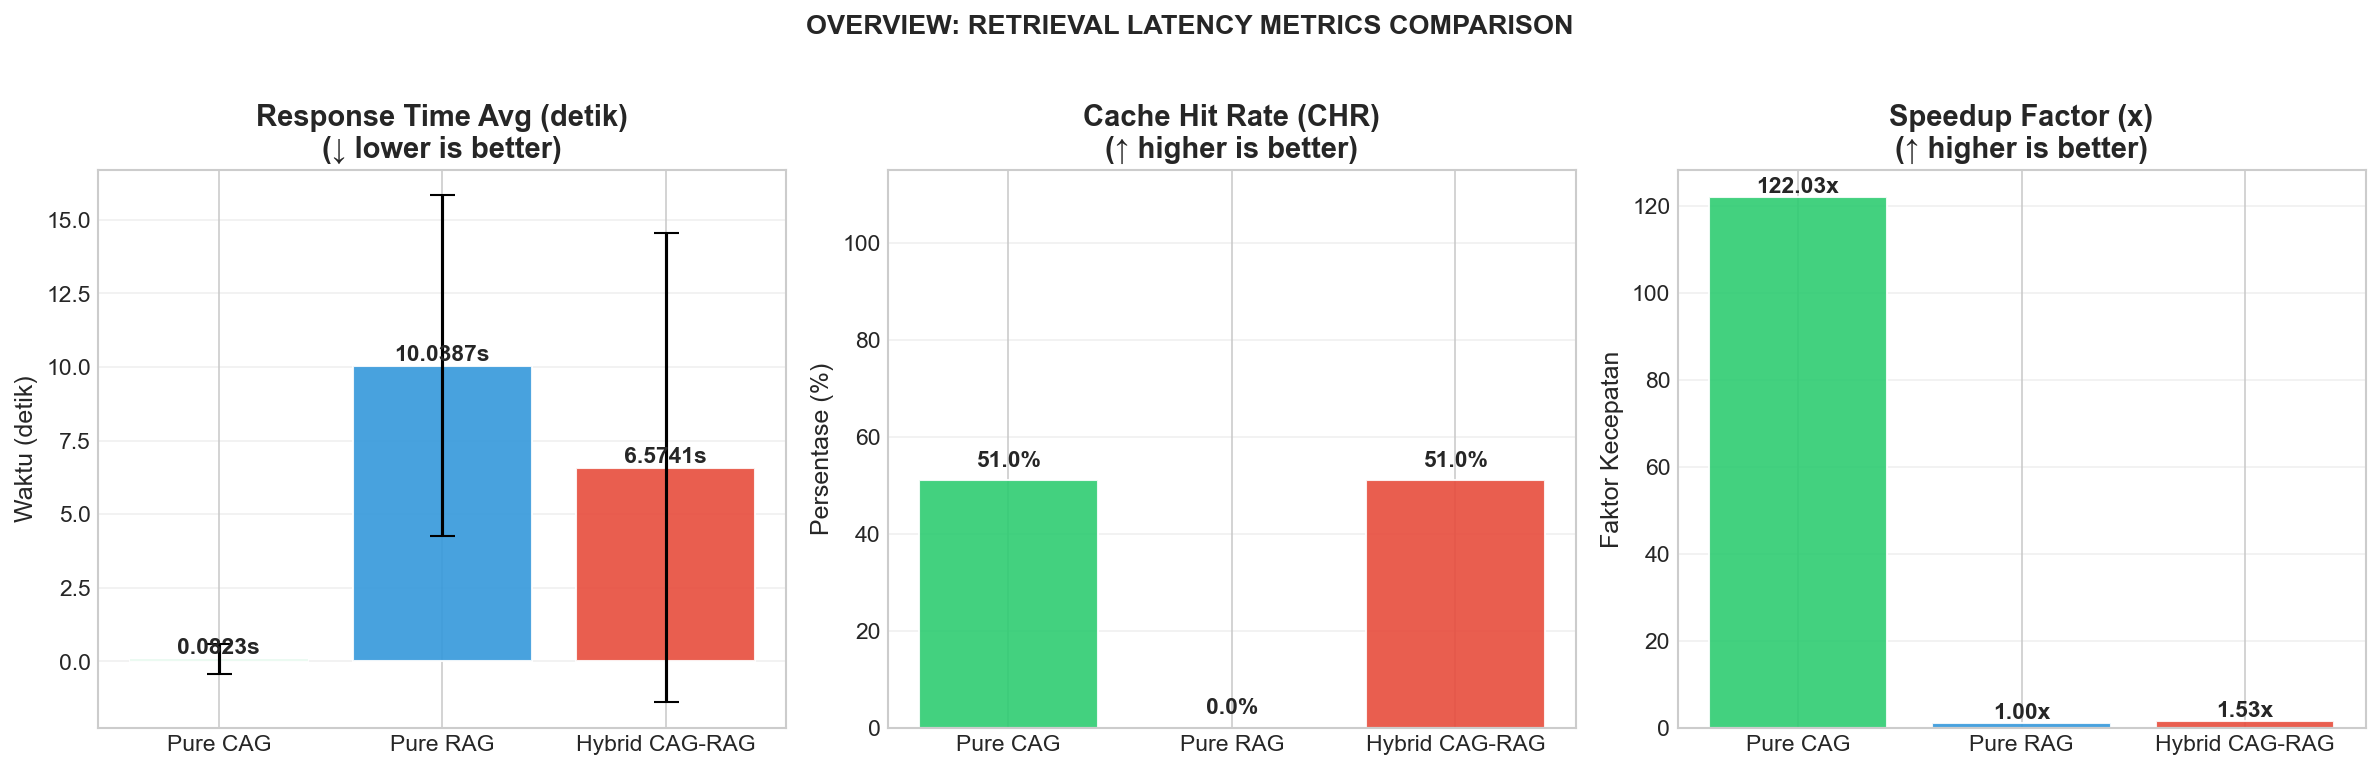

In [33]:
# [Cell 60]
# ============================================================================
# OVERVIEW: LATENCY COMPARISON
# ============================================================================
frameworks = [f for f in ['CAG', 'RAG', 'HYBRID'] if framework_metrics.get(f)]
times = [float(framework_metrics[fw]['time_avg']) for fw in frameworks]
stds = [float(framework_metrics[fw]['time_std']) for fw in frameworks]
chrs = [float(framework_metrics[fw]['chr']) * 100 for fw in frameworks]

# Hitung Speedup
speedup_cag = (framework_metrics['RAG']['time_avg'] / framework_metrics['CAG']['time_avg']) if 'CAG' in frameworks else 1.0
speedup_hybrid = (framework_metrics['RAG']['time_avg'] / framework_metrics['HYBRID']['time_avg']) if 'HYBRID' in frameworks else 1.0
speedups = [speedup_cag if fw == 'CAG' else (speedup_hybrid if fw == 'HYBRID' else 1.0) for fw in frameworks]

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 5))

# Plot Response Time
bars1 = ax1.bar([LABELS[f] for f in frameworks], times, yerr=stds, capsize=6, color=[COLORS[f] for f in frameworks], edgecolor='white', alpha=0.9)
for bar, val in zip(bars1, times):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, f'{val:.4f}s', ha='center', va='bottom', fontweight='bold')
ax1.set_title('Response Time Avg (detik)\n(↓ lower is better)', fontweight='bold')
ax1.set_ylabel('Waktu (detik)')
ax1.grid(axis='y', alpha=0.3)

# Plot CHR
bars2 = ax2.bar([LABELS[f] for f in frameworks], chrs, color=[COLORS[f] for f in frameworks], edgecolor='white', alpha=0.9)
for bar, val in zip(bars2, chrs):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')
ax2.set_title('Cache Hit Rate (CHR)\n(↑ higher is better)', fontweight='bold')
ax2.set_ylabel('Persentase (%)')
ax2.set_ylim(0, 115)
ax2.grid(axis='y', alpha=0.3)

# Plot Speedup
bars3 = ax3.bar([LABELS[f] for f in frameworks], speedups, color=[COLORS[f] for f in frameworks], edgecolor='white', alpha=0.9)
for bar, val in zip(bars3, speedups):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, f'{val:.2f}x', ha='center', va='bottom', fontweight='bold')
ax3.set_title('Speedup Factor (x)\n(↑ higher is better)', fontweight='bold')
ax3.set_ylabel('Faktor Kecepatan')
ax3.grid(axis='y', alpha=0.3)

plt.suptitle('OVERVIEW: RETRIEVAL LATENCY METRICS COMPARISON', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../logs/thesis_charts/overview_latency_comparison.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


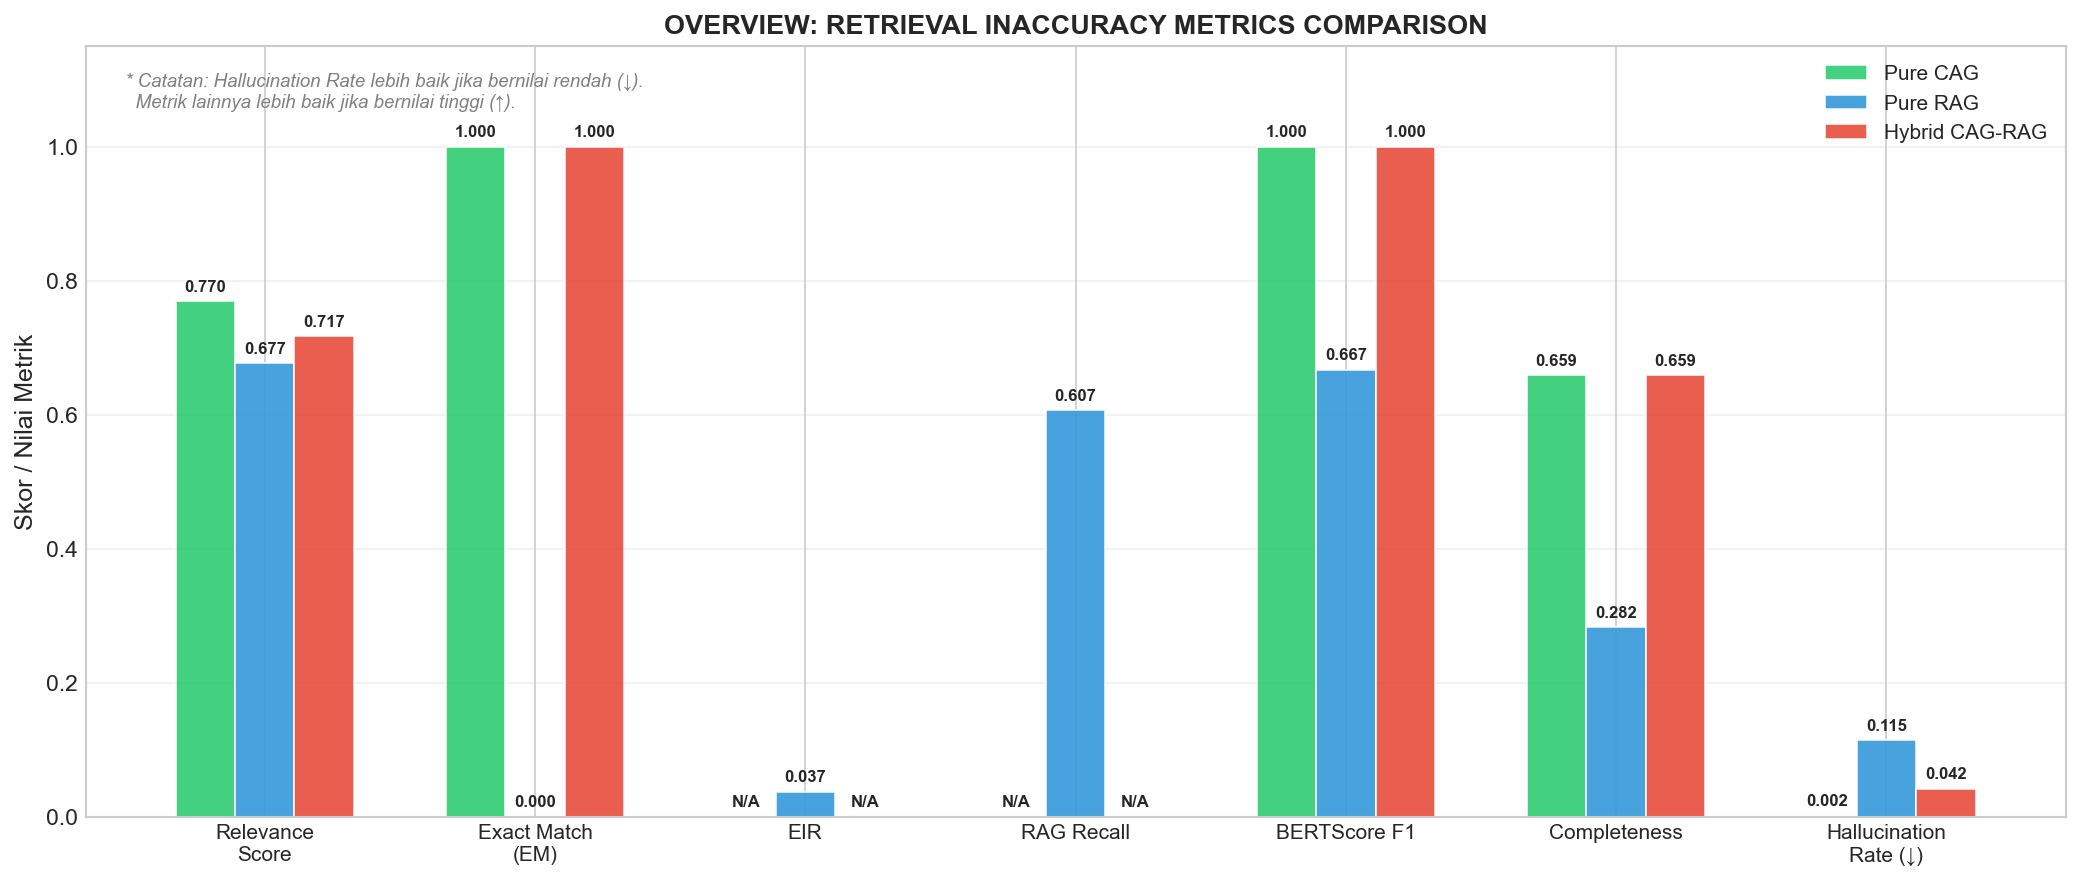

In [34]:
# [Cell 61]
# ============================================================================
# OVERVIEW: INACCURACY COMPARISON (7 METRICS GROUPED)
# ============================================================================
width = 0.22
x = np.arange(len(inaccuracy_keys))
fig, ax = plt.subplots(figsize=(14, 6))

for idx, fw in enumerate(frameworks):
    raw_vals = [framework_metrics[fw].get(k) for k in inaccuracy_keys]
    vals = [0.0 if v is None or (isinstance(v, float) and np.isnan(v)) else v for v in raw_vals]
    offset = (idx - (len(frameworks) - 1) / 2) * width
    
    bars = ax.bar(
        x + offset, vals, width, 
        label=LABELS[fw], color=COLORS[fw], 
        edgecolor='white', linewidth=0.8, alpha=0.9
    )
    
    for bar, v_raw in zip(bars, raw_vals):
        lbl = "N/A" if v_raw is None or (isinstance(v_raw, float) and np.isnan(v_raw)) else f"{v_raw:.3f}"
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                lbl, ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels([
    'Relevance\nScore', 'Exact Match\n(EM)', 'EIR', 
    'RAG Recall', 'BERTScore F1', 'Completeness', 'Hallucination\nRate (↓)'
], fontsize=10)
ax.set_ylabel('Skor / Nilai Metrik')
ax.set_title('OVERVIEW: RETRIEVAL INACCURACY METRICS COMPARISON', fontsize=13, fontweight='bold')
ax.set_ylim(0, 1.15)
ax.legend(loc='upper right', fontsize=10, framealpha=0.9)
ax.grid(axis='y', alpha=0.3)

ax.annotate('* Catatan: Hallucination Rate lebih baik jika bernilai rendah (↓).\n  Metrik lainnya lebih baik jika bernilai tinggi (↑).', 
            xy=(0.02, 0.92), xycoords='axes fraction', fontsize=9, fontstyle='italic', color='gray')

plt.tight_layout()
plt.savefig('../logs/thesis_charts/overview_inaccuracy_comparison.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


## [Cell 62] Statistical Significance Testing
Paired t-test (p < 0.05) + Cohen's d effect size.

🔬 STATISTICAL SIGNIFICANCE TESTS (Paired t-test, NaN-aware)
   H0: No difference between RAG and Hybrid CAG-RAG
   H1: Significant difference exists (p < 0.05)
   NaN positions (FAQ path) are excluded from all tests.

  Metric                     N   RAG µ   CAG µ   t-stat   p-value       d  Result
  ----------------------------------------------------------------------------------
  Response Time            200 10.0387  6.5741    7.316    0.0000   0.517  ✅ H1 supported
  Relevance Score          200  0.6768  0.7167   -5.333    0.0000   0.377  ✅ H1 supported
  Exact Match              100  0.0000  1.0000     -inf    0.0000   0.000  ✅ H1 supported
  EIR                     (insufficient data — need ≥ 2 queries)
  RAG Recall              (insufficient data — need ≥ 2 queries)
  BERTScore F1             100  0.6670  1.0000  -58.852    0.0000   5.885  ✅ H1 supported
  Completeness             100  0.2824  0.6587  -10.227    0.0000   1.023  ✅ H1 supported
  Hallucination Rate       200  0.1

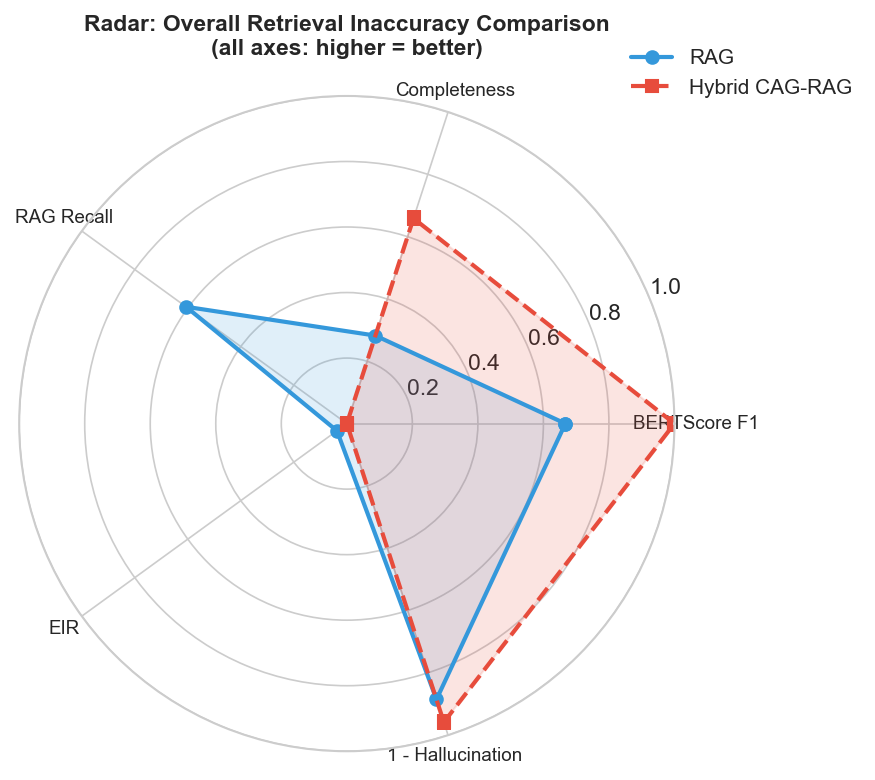

✅ Saved: logs/radar_comparison.png


In [35]:
# [Cell 63]
# =============================================================================
# 🔬 STATISTICAL SIGNIFICANCE TESTING  (Paired t-test + Cohen's d)
# =============================================================================
import numpy as np
from scipy import stats
import pandas as pd
import matplotlib.pyplot as plt

# 1. Helper function untuk Paired T-Test (NaN-aware)
def paired_ttest(a, b):
    # Filter pasangan data yang bernilai NaN atau None
    valid_pairs = []
    for x, y in zip(a, b):
        if x is None or y is None:
            continue
        if isinstance(x, (int, float)) and np.isnan(x):
            continue
        if isinstance(y, (int, float)) and np.isnan(y):
            continue
        valid_pairs.append((float(x), float(y)))
        
    n_valid = len(valid_pairs)
    if n_valid < 2:
        return float('nan'), float('nan'), n_valid
        
    a_clean = [p[0] for p in valid_pairs]
    b_clean = [p[1] for p in valid_pairs]
    res = stats.ttest_rel(a_clean, b_clean)
    return res.statistic, res.pvalue, n_valid

# 2. Helper function untuk Cohen's d (NaN-aware)
def cohens_d(a, b):
    # Filter pasangan data yang bernilai NaN atau None
    valid_pairs = []
    for x, y in zip(a, b):
        if x is None or y is None:
            continue
        if isinstance(x, (int, float)) and np.isnan(x):
            continue
        if isinstance(y, (int, float)) and np.isnan(y):
            continue
        valid_pairs.append((float(x), float(y)))
        
    n_valid = len(valid_pairs)
    if n_valid < 2:
        return float('nan')
        
    diffs = np.array([p[0] - p[1] for p in valid_pairs])
    mean_diff = np.mean(diffs)
    std_diff = np.std(diffs, ddof=1)
    if std_diff == 0:
        return 0.0
    return abs(mean_diff) / std_diff


# 3. Main Testing Code
if not cag_m:
    print("⚠️  CAG results not available, skipping statistical tests.")
else:
    print("=" * 72)
    print("🔬 STATISTICAL SIGNIFICANCE TESTS (Paired t-test, NaN-aware)")
    print("   H0: No difference between RAG and Hybrid CAG-RAG")
    print("   H1: Significant difference exists (p < 0.05)")
    print("   NaN positions (FAQ path) are excluded from all tests.")
    print("=" * 72)

    # Metrik yang diuji — arah = 'lower' → CAG harus lebih rendah, 'higher' → CAG harus lebih tinggi
    test_metrics = [
        # (label,              rag_list,             cag_list,             better_direction)
        # ── Latency ──────────────────────────────────────────────────────────
        ("Response Time",      rag_m['_time'],       cag_m['_time'],       "lower"),
        # ── Relevance ─────────────────────────────────────────────────────────
        ("Relevance Score",    rag_m['_rel'],        cag_m['_rel'],        "higher"),
        # ── Retrieval / Answer Alignment ─────────────────────────────────────
        ("Exact Match",        rag_m['_em'],         cag_m['_em'],         "higher"),
        ("EIR",                rag_m['_eir'],        cag_m['_eir'],        "higher"),
        ("RAG Recall",         rag_m['_recall'],     cag_m['_recall'],     "higher"),
        ("BERTScore F1",       rag_m['_bert'],       cag_m['_bert'],       "higher"),
        ("Completeness",       rag_m['_comp'],       cag_m['_comp'],       "higher"),
        # ── Inaccuracy ────────────────────────────────────────────────────────
        ("Hallucination Rate", rag_m['_hall'],       cag_m['_hall'],       "lower"),
    ]

    stat_rows = []
    print(f"\n  {'Metric':<22} {'N':>5} {'RAG µ':>7} {'CAG µ':>7} {'t-stat':>8} {'p-value':>9} {'d':>7}  Result")
    print("  " + "-" * 82)

    for lbl, rag_vals, cag_vals, direction in test_metrics:
        if len(rag_vals) < 2 or len(cag_vals) < 2:
            print(f"  {lbl:<22}  (insufficient data — need ≥ 2 queries)")
            continue

        t_stat, p_val, n_valid = paired_ttest(rag_vals, cag_vals)
        d                      = cohens_d(rag_vals, cag_vals)

        if n_valid < 2:
            print(f"  {lbl:<22}  (no valid pairs after NaN removal — skipped)")
            continue

        # Means computed only on non-NaN values for fair representation
        rag_clean = [x for x in rag_vals if not (isinstance(x, float) and np.isnan(x))]
        cag_clean = [x for x in cag_vals if not (isinstance(x, float) and np.isnan(x))]
        rag_mu    = round(float(np.mean(rag_clean)), 4) if rag_clean else float('nan')
        cag_mu    = round(float(np.mean(cag_clean)), 4) if cag_clean else float('nan')

        significant = not np.isnan(p_val) and p_val < 0.05

        # Check if direction is as expected
        if direction == "lower":
            direction_ok = cag_mu <= rag_mu
        else:
            direction_ok = cag_mu >= rag_mu

        if significant and direction_ok:
            result = "✅ H1 supported"
        elif significant and not direction_ok:
            result = "⚠️  sig. but reversed"
        else:
            result = "❌ not significant"

        n_str = f"{n_valid}" if n_valid == len(rag_vals) else f"{n_valid}*"
        print(f"  {lbl:<22} {n_str:>5} {rag_mu:>7.4f} {cag_mu:>7.4f} "
              f"{t_stat:>8.3f} {p_val:>9.4f} {d:>7.3f}  {result}")
        stat_rows.append({
            'Metric': lbl, 'N': n_valid, 'RAG_mean': rag_mu, 'CAG_mean': cag_mu,
            't_stat': t_stat, 'p_value': p_val, "Cohen_d": d,
            'significant': significant, 'direction_ok': direction_ok
        })

    print("\n  * N < total = beberapa posisi NaN (FAQ path) dikecualikan")
    print("  Legend: ✅ Hypothesis supported  |  ❌ Not significant  |  ⚠️  Unexpected direction")
    print(f"  α = 0.05  |  Effect size: small < 0.2,  medium 0.2–0.8,  large > 0.8")

    # Radar chart for visual comparison
    stat_df = pd.DataFrame(stat_rows)

    # Radar chart
    radar_metrics = ['BERTScore F1', 'Completeness', 'RAG Recall', 'EIR']
    rag_radar  = [rag_m['bert'], rag_m['comp'], rag_m['recall'], rag_m['eir']]
    cag_radar  = [cag_m['bert'], cag_m['comp'], cag_m['recall'], cag_m['eir']]

    # Invert inaccuracy metrics so higher = better on radar
    rag_hall_val = rag_m['hall'] if not (isinstance(rag_m['hall'], float) and np.isnan(rag_m['hall'])) else 0.5
    cag_hall_val = cag_m['hall'] if not (isinstance(cag_m['hall'], float) and np.isnan(cag_m['hall'])) else 0.5

    radar_metrics += ['1 - Hallucination']
    rag_radar  += [1 - rag_hall_val]
    cag_radar  += [1 - cag_hall_val]

    # Replace any remaining NaN with 0 for radar chart rendering
    rag_radar = [v if not (isinstance(v, float) and np.isnan(v)) else 0.0 for v in rag_radar]
    cag_radar = [v if not (isinstance(v, float) and np.isnan(v)) else 0.0 for v in cag_radar]

    N   = len(radar_metrics)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    rag_r  = rag_radar + [rag_radar[0]]
    cag_r  = cag_radar + [cag_radar[0]]
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
    ax.plot(angles, rag_r, 'o-', color='#3498db', linewidth=2, label='RAG')
    ax.fill(angles, rag_r, alpha=0.15, color='#3498db')
    ax.plot(angles, cag_r, 's--', color='#e74c3c', linewidth=2, label='Hybrid CAG-RAG')
    ax.fill(angles, cag_r, alpha=0.15, color='#e74c3c')
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_metrics, fontsize=9)
    ax.set_ylim(0, 1)
    ax.set_title('Radar: Overall Retrieval Inaccuracy Comparison\n(all axes: higher = better)',
                 fontsize=11, fontweight='bold', pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)
    plt.tight_layout()
    plt.savefig('../logs/radar_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✅ Saved: logs/radar_comparison.png")


## [Cell 64] Save & Export

In [36]:
# [Cell 65]
# Save & Export All Results

import json
ts = datetime.now().strftime('%Y%m%d_%H%M%S')
os.makedirs('../logs', exist_ok=True)

speedup_hybrid = (rag_m['time_avg'] / cag_m['time_avg']) if (cag_m and cag_m['time_avg'] > 0) else None
speedup_cag    = (rag_m['time_avg'] / pure_cag_m['time_avg']) if (pure_cag_m and pure_cag_m['time_avg'] > 0) else None

cag_hits = sum(1 for x in pure_cag_res if x.get('cache')) if pure_cag_res else 0
hybrid_hits = sum(1 for x in cag_res if x.get('cache')) if cag_res else 0

# 1. Summary metrics JSON
summary_export = {
    'timestamp':    ts,
    'dataset_size': len(dataset),
    'rag': {k: v for k, v in rag_m.items() if not k.startswith('_') and k != 'per_query'},
    'cag_pure': ({k: v for k, v in pure_cag_m.items() if not k.startswith('_') and k != 'per_query'}
                 if pure_cag_m else None),
    'hybrid': ({k: v for k, v in cag_m.items() if not k.startswith('_') and k != 'per_query'}
               if cag_m else None),
    'speedup_hybrid': round(speedup_hybrid, 4) if speedup_hybrid else None,
    'speedup_cag': round(speedup_cag, 4) if speedup_cag else None,
    'cache_hits': {
        'cag_pure': cag_hits,
        'hybrid': hybrid_hits,
    },
}

json_path = f'../logs/eval_summary_{ts}.json'
with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(summary_export, f, indent=2, ensure_ascii=False)
print(f"Summary JSON     : {json_path}")

# 2. Per-query CSV — RAG
if rag_m['per_query']:
    rag_csv = f'../logs/eval_rag_perquery_{ts}.csv'
    pd.DataFrame(rag_m['per_query']).to_csv(rag_csv, index=False)
    print(f"RAG per-query    : {rag_csv}")

# 3. Per-query CSV — CAG (pure)
if pure_cag_m and pure_cag_m['per_query']:
    cag_csv = f'../logs/eval_cag_pure_perquery_{ts}.csv'
    pd.DataFrame(pure_cag_m['per_query']).to_csv(cag_csv, index=False)
    print(f"CAG per-query    : {cag_csv}")

# 4. Per-query CSV — Hybrid
if cag_m and cag_m['per_query']:
    hybrid_csv = f'../logs/eval_hybrid_perquery_{ts}.csv'
    pd.DataFrame(cag_m['per_query']).to_csv(hybrid_csv, index=False)
    print(f"Hybrid per-query : {hybrid_csv}")

# 5. Statistical results CSV
if cag_m and 'stat_df' in dir():
    stat_csv = f'../logs/eval_stats_{ts}.csv'
    stat_df.to_csv(stat_csv, index=False)
    print(f"Statistics       : {stat_csv}")

# Key Findings
print("\n" + "=" * 65)
print("KEY FINDINGS  —  CAG vs RAG vs Hybrid CAG-RAG")
print("=" * 65)

print(f"\n  RQ1 LATENCY")
if pure_cag_m:
    print(f"    CAG avg time   : {pure_cag_m['time_avg']:.3f}s +/- {pure_cag_m['time_std']:.3f}s")
    print(f"    CAG CHR        : {pure_cag_m['chr']:.1f}% ({cag_hits}/{len(pure_cag_res)})")
print(f"    RAG avg time   : {rag_m['time_avg']:.3f}s +/- {rag_m['time_std']:.3f}s")
if cag_m:
    print(f"    Hybrid avg time: {cag_m['time_avg']:.3f}s +/- {cag_m['time_std']:.3f}s")
    print(f"    Speedup (RAG/Hybrid): {speedup_hybrid:.2f}x" if speedup_hybrid else "    Speedup (RAG/Hybrid): N/A")
    print(f"    Hybrid CHR     : {cag_m['chr']:.1f}% ({hybrid_hits}/{len(cag_res)})")

print(f"\n  RQ2 INACCURACY")
if cag_m:
    hall_d = rag_m['hall'] - cag_m['hall']
    rel_d  = cag_m['rel']  - rag_m['rel']
    print(f"    Hallucination  RAG={rag_m['hall']:.4f}  Hybrid={cag_m['hall']:.4f}  delta={hall_d:+.4f}")
    print(f"    Relevance      RAG={rag_m['rel']:.4f}  Hybrid={cag_m['rel']:.4f}  delta={rel_d:+.4f}")

    print(f"\n  GROUND-TRUTH ALIGNMENT")
    print(f"    BERTScore F1   RAG={rag_m['bert']:.4f}  Hybrid={cag_m['bert']:.4f}  delta={cag_m['bert']-rag_m['bert']:+.4f}")
    print(f"    Completeness   RAG={rag_m['comp']:.4f}  Hybrid={cag_m['comp']:.4f}  delta={cag_m['comp']-rag_m['comp']:+.4f}")
    print(f"    Exact Match    RAG={rag_m['em']:.4f}  Hybrid={cag_m['em']:.4f}  delta={cag_m['em']-rag_m['em']:+.4f}")

print("\nEvaluation complete.")
print(f"Outputs saved to: logs/")

Summary JSON     : ../logs/eval_summary_20260701_154517.json
RAG per-query    : ../logs/eval_rag_perquery_20260701_154517.csv
CAG per-query    : ../logs/eval_cag_pure_perquery_20260701_154517.csv
Hybrid per-query : ../logs/eval_hybrid_perquery_20260701_154517.csv
Statistics       : ../logs/eval_stats_20260701_154517.csv

KEY FINDINGS  —  CAG vs RAG vs Hybrid CAG-RAG

  RQ1 LATENCY
    CAG avg time   : 0.082s +/- 0.513s
    CAG CHR        : 0.5% (102/200)
    RAG avg time   : 10.039s +/- 5.790s
    Hybrid avg time: 6.574s +/- 7.971s
    Speedup (RAG/Hybrid): 1.53x
    Hybrid CHR     : 0.5% (102/200)

  RQ2 INACCURACY
    Hallucination  RAG=0.1147  Hybrid=0.0417  delta=+0.0730
    Relevance      RAG=0.6768  Hybrid=0.7167  delta=+0.0399

  GROUND-TRUTH ALIGNMENT
    BERTScore F1   RAG=0.6670  Hybrid=1.0000  delta=+0.3329
    Completeness   RAG=0.2824  Hybrid=0.6587  delta=+0.3763
    Exact Match    RAG=0.0000  Hybrid=1.0000  delta=+1.0000

Evaluation complete.
Outputs saved to: logs/
